In [2]:
#LOAD MODULES
import tensorflow as tf

assert tf.__version__.startswith('2')
from os import listdir
import numpy as np
#import segmentation_models as sm
import cv2

#sm.set_framework('tf.keras')
#sm.framework()
from PIL import Image
import tensorflow as tf
from scipy import ndimage
import pandas as pd

import copy
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
from keras import backend as K
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import random
import copy

/Users/anna.lisitsyna/venvs/tf/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [3]:
#DEFINE PATHS AND CONSTANTS
model_paths = []
#model_paths.append("model_adjRevHuber_overlap_orig_Adam_lr0.001_MAE_1_32_addep8")
model_paths.append("model_adjRevHuber_overlap_orig_Adam_lr0.001_RevHub_1_22_addep7")
model_paths.append("model_shuffle_adjRevHuber_overlap_orig_Adam_lr0.001_RevHub_1_33_addep4")
#model_paths.append("model_adjRevHuber_overlap_orig_Adam_lr0.001_RevHub_1_22_addep7")
#model_paths.append("/Users/anna.lisitsyna/Downloads/scripts/Current scripts/model_adjRevHuber_init_Adam_lr0.001_RevHub_1_ep35")
#model_paths.append("/Users/anna.lisitsyna/Downloads/scripts/Current scripts/model_RevHuber_nonoverlap_orig_Adam_lr0.001_RevHub_1_35_addep35")
#model_paths.append("/Users/anna.lisitsyna/Downloads/scripts/Current scripts/model_adjRevHuber_overlap_orig_Adam_lr0.001_RevHub_1_67_addep11")
#model_paths.append("/Users/anna.lisitsyna/Downloads/scripts/Current scripts/model_RevHuber_overlap_extra_Adam_lr0.001_RevHub_1_11_ep10")

model_losses = []

#model_losses.append([[0.10662628710269928, 0.08825436234474182, 0.0870957002043724, 0.08690043538808823, 0.08488800376653671, 0.08507337421178818, 0.08540317416191101, 0.08353088051080704, 0.08290629088878632, 0.08285502344369888, 0.08170882612466812, 0.08097963035106659, 0.08025012910366058, 0.07995596528053284, 0.0790625587105751, 0.07878096401691437, 0.07823756337165833, 0.07829127460718155, 0.07785069197416306, 0.07749690860509872, 0.07701807469129562, 0.07699042558670044, 0.07639093697071075, 0.0758465975522995, 0.07543797791004181, 0.07550228387117386, 0.07480023801326752, 0.07497955113649368, 0.07504148781299591, 0.0744490772485733, 0.07404953241348267, 0.07353795319795609, 0.07337804138660431, 0.07362803816795349, 0.07322514802217484, 0.07295191287994385, 0.07293640077114105, 0.07288366556167603, 0.07302284240722656, 0.07207955420017242, 0.07208430022001266, 0.0721474140882492, 0.07169704139232635, 0.07193098217248917, 0.07103962451219559, 0.07115928083658218, 0.07067651301622391, 0.07125455886125565, 0.07015278935432434, 0.070249043405056, 0.07040119916200638, 0.07008779793977737, 0.06973998993635178, 0.06936495006084442, 0.06955191493034363, 0.06892646104097366, 0.06885569542646408, 0.06842634826898575, 0.06816517561674118, 0.06813245266675949, 0.06777403503656387, 0.06777552515268326, 0.06771191209554672, 0.06731250882148743, 0.0667768195271492, 0.06677455455064774, 0.06659715622663498, 0.0665787011384964, 0.06639132648706436, 0.06653954088687897, 0.06621620059013367, 0.06639246642589569, 0.06651884317398071, 0.06602830439805984, 0.06572972983121872, 0.06539677828550339, 0.06563454121351242, 0.06525539606809616, 0.06550687551498413, 0.06505466997623444, 0.06508206576108932, 0.06531981378793716, 0.06484581530094147, 0.06502220034599304, 0.06474294513463974, 0.06470899283885956, 0.06473024934530258, 0.06429712474346161, 0.06423046439886093, 0.06411264836788177, 0.06386902183294296, 0.0637701004743576, 0.06393852829933167, 0.0639495998620987, 0.06383071839809418, 0.0636930838227272, 0.0635395422577858, 0.06354216486215591, 0.06339230388402939, 0.06323856860399246, 0.06314319372177124, 0.06312540173530579, 0.06315044313669205, 0.06313890963792801, 0.06278813630342484, 0.06260394304990768, 0.06268849968910217, 0.06258505582809448, 0.062391817569732666, 0.06223079934716225], 
#                    [0.510901927947998, 0.15491364896297455, 0.1441573053598404, 0.10115129500627518, 0.13221457600593567, 0.1009441539645195, 0.08736343681812286, 0.15162235498428345, 0.09487753361463547, 0.12647855281829834, 0.09609044343233109, 0.09145572781562805, 0.08985064178705215, 0.14289456605911255, 0.09513860195875168, 0.1070837751030922, 0.09644946455955505, 0.09026377648115158, 0.08779438585042953, 0.1539367437362671, 0.11895239353179932, 0.08787652105093002, 0.12524044513702393, 0.14169301092624664, 0.1141873225569725, 0.11181675642728806, 0.10922916978597641, 0.11311398446559906, 0.14684191346168518, 0.11987010389566422, 0.10868218541145325, 0.13445626199245453, 0.109414242208004, 0.12060187011957169, 0.09817790240049362, 0.09837544709444046, 0.10476680099964142, 0.11937286704778671, 0.10009385645389557, 0.08388174325227737, 0.13182151317596436, 0.11931944638490677, 0.1164800152182579, 0.14135465025901794, 0.0860423743724823, 0.13711382448673248, 0.10301875323057175, 0.08484038710594177, 0.1748577505350113, 0.0947917252779007, 0.10234425961971283, 0.09548608958721161, 0.16081596910953522, 0.17831455171108246, 0.09323401004076004, 0.10286084562540054, 0.09354925900697708, 0.1678648144006729, 0.10980197787284851, 0.10363450646400452, 0.1268075555562973, 0.10132179409265518, 0.10620883852243423, 0.14388030767440796, 0.11034617573022842, 0.11277282983064651, 0.10902974009513855, 0.09369871020317078, 0.10556727647781372, 0.10052099078893661, 0.11089307069778442, 0.11403729766607285, 0.10687121748924255, 0.10121358186006546, 0.12200602889060974, 0.10460177063941956, 0.1086421012878418, 0.10620037466287613, 0.10575083643198013, 0.10368257761001587, 0.10992322862148285, 0.09976311773061752, 0.11733055859804153, 0.11656802147626877, 0.12042539566755295, 0.10036221891641617, 0.10725501924753189, 0.1040857583284378, 0.119809091091156, 0.11262486129999161, 0.10660392045974731, 0.10666655749082565, 0.11605329811573029, 0.10993649810552597, 0.10718059539794922, 0.1064256802201271, 0.11326798051595688, 0.1038203313946724, 0.11679141968488693, 0.11683280766010284, 0.10352589935064316, 0.1040501818060875, 0.10383417457342148, 0.11291420459747314, 0.10858256369829178, 0.10412877798080444, 0.10854897648096085, 0.11046305298805237, 0.11254711449146271, 0.11150478571653366]])
model_losses.append([[0.1246727705001831, 0.09698298573493958, 0.09115637093782425, 0.08926278352737427, 0.0884089544415474, 0.08758243918418884, 0.08837506175041199, 0.08687672764062881, 0.08588668704032898, 0.08549783378839493, 0.08550365269184113, 0.08390408754348755, 0.08350930362939835, 0.08341211825609207, 0.08295189589262009, 0.0831892341375351, 0.08163759112358093, 0.08171150088310242, 0.08149711787700653, 0.0806291252374649, 0.08086797595024109, 0.0802670493721962, 0.07975634187459946, 0.08029007166624069, 0.0798771008849144, 0.07928761094808578, 0.07917053252458572, 0.07812143862247467, 0.0783950686454773, 0.07870862632989883, 0.07791659235954285, 0.07807137072086334, 0.07768378406763077, 0.0771411657333374, 0.07769741117954254, 0.07685752213001251, 0.07615479826927185, 0.0762113705277443, 0.07678593695163727, 0.07761196047067642, 0.07611642777919769, 0.07630494982004166, 0.07571139186620712, 0.07503202557563782, 0.07255397737026215, 0.07201430946588516, 0.07192923128604889, 0.07187657058238983, 0.07108423858880997, 0.0710773840546608, 0.07084483653306961, 0.07063346356153488, 0.070536769926548, 0.07015591859817505, 0.07023756206035614, 0.07007929682731628, 0.06977397948503494, 0.0698898509144783, 0.06961259245872498, 0.06915956735610962, 0.07024570554494858, 0.06896020472049713, 0.07136902213096619, 0.06947547942399979, 0.06983459740877151, 0.06972102075815201, 0.06876229494810104, 0.06913814693689346, 0.06931255012750626, 0.0687214657664299, 0.06972244381904602, 0.06917215138673782, 0.06955942511558533, 0.06823822855949402, 0.06889688223600388, 0.06854687631130219, 0.06820032745599747, 0.06798148900270462, 0.06814588606357574, 0.06784186512231827, 0.06752392649650574, 0.06727393716573715, 0.06729168444871902, 0.06734518706798553, 0.06757833063602448, 0.06680353730916977, 0.067031629383564, 0.0664481520652771], 
                   [0.34333834052085876, 0.24541230499744415, 0.2506318986415863, 0.607817530632019, 0.2214539498090744, 0.21054506301879883, 0.167836531996727, 0.1939195990562439, 0.2299528419971466, 0.6844321489334106, 0.1693952977657318, 0.17157500982284546, 0.21976783871650696, 0.2054634541273117, 0.21234585344791412, 0.15302595496177673, 0.41740140318870544, 0.17307226359844208, 0.17322610318660736, 0.1365673542022705, 0.20044104754924774, 0.11909846216440201, 0.1383073776960373, 0.192335307598114, 0.18898090720176697, 0.18965277075767517, 0.14726094901561737, 0.17661777138710022, 0.1589144468307495, 0.1771731972694397, 0.19203153252601624, 0.22985275089740753, 0.17667721211910248, 0.21207408607006073, 0.1499452143907547, 0.13368092477321625, 0.18305635452270508, 0.17018194496631622, 0.16438709199428558, 0.17764191329479218, 0.25656989216804504, 0.2378886640071869, 0.2262503057718277, 0.162810280919075, 0.24910813570022583, 0.2831793427467346, 0.19685500860214233, 0.3479836583137512, 0.27186447381973267, 0.24557045102119446, 0.21859031915664673, 0.21203550696372986, 0.25846242904663086, 0.3422355651855469, 0.18156883120536804, 0.23198363184928894, 0.22348685562610626, 0.20328868925571442, 0.21560832858085632, 0.26471811532974243, 0.3529115617275238, 0.25085487961769104, 0.14166726171970367, 0.1730102151632309, 0.26029640436172485, 0.22550146281719208, 0.18272747099399567, 0.19520480930805206, 0.14275656640529633, 0.14081446826457977, 0.156868577003479, 0.1686183363199234, 0.3077210783958435, 0.21601946651935577, 0.11673645675182343, 0.14918437600135803, 0.1957317739725113, 0.19913306832313538, 0.15802475810050964, 0.202071875333786, 0.12653641402721405, 0.23641467094421387, 0.29519733786582947, 0.1404448002576828, 0.165806844830513, 0.5452651977539062, 0.26934173703193665, 0.34909525513648987]])
model_losses.append([[0.10693985223770142, 0.08466926217079163, 0.08284956961870193, 0.08250191062688828, 0.08024376630783081, 0.07889949530363083, 0.07839096337556839, 0.07717009633779526, 0.07604657858610153, 0.07582898437976837, 0.07535652071237564, 0.07415062934160233, 0.07338545471429825, 0.07314825057983398, 0.07267899811267853, 0.072869211435318, 0.07177328318357468, 0.07216808199882507, 0.07181133329868317, 0.07153923064470291, 0.07084023207426071, 0.07054106146097183, 0.070380799472332, 0.07039033621549606, 0.0698893815279007, 0.06973974406719208, 0.06895288825035095, 0.06892819702625275, 0.06881596148014069, 0.0689038634300232, 0.06868284195661545, 0.06808391958475113, 0.06775829941034317, 0.06789947301149368, 0.06815149635076523, 0.06724511831998825, 0.06718544661998749, 0.06662975996732712, 0.06666732579469681, 0.06671921908855438, 0.0665205642580986, 0.06598465889692307, 0.06611312925815582, 0.06554003804922104, 0.06555027514696121, 0.06514117121696472, 0.06545673310756683, 0.06540653109550476, 0.06524728983640671, 0.06481236219406128, 0.06441784650087357, 0.06422004848718643, 0.06415197998285294, 0.06430437415838242, 0.06376970559358597, 0.06364127993583679, 0.06378164887428284, 0.06358188390731812, 0.06389057636260986, 0.06341560930013657, 0.06327319145202637, 0.0631314069032669, 0.06279327720403671, 0.06280598044395447, 0.0626203790307045, 0.062125835567712784], 
                    [0.18035148084163666, 0.2370465248823166, 0.29603034257888794, 0.18270424008369446, 0.27978137135505676, 0.21997927129268646, 0.27206385135650635, 0.27901360392570496, 0.285910040140152, 0.26979705691337585, 0.28688105940818787, 0.265865296125412, 0.1524066925048828, 0.24155621230602264, 0.2840230166912079, 0.27499136328697205, 0.178483784198761, 0.29838699102401733, 0.1414511352777481, 0.2825482487678528, 0.2573806941509247, 0.26483792066574097, 0.28898826241493225, 0.2941907048225403, 0.28153711557388306, 0.29831013083457947, 0.2748125493526459, 0.28164562582969666, 0.2610290050506592, 0.2322794795036316, 0.23474885523319244, 0.2637137174606323, 0.2630014717578888, 0.27445167303085327, 0.24802739918231964, 0.266815721988678, 0.24461299180984497, 0.26888546347618103, 0.22756622731685638, 0.2481415867805481, 0.2685180902481079, 0.25109246373176575, 0.26950353384017944, 0.2696593701839447, 0.2714484930038452, 0.288737416267395, 0.284245103597641, 0.19855283200740814, 0.25679174065589905, 0.28140872716903687, 0.2850302755832672, 0.2950998544692993, 0.2872404456138611, 0.3033776581287384, 0.30492156744003296, 0.2920847535133362, 0.28305521607398987, 0.26650938391685486, 0.31105268001556396, 0.2879750728607178, 0.2946034073829651, 0.32109567523002625, 0.3183908462524414, 0.2991138994693756, 0.2842658460140228, 0.3021458089351654]])


model_r2 = []                
model_r2.append([[-1.0934221744537354, -0.0956515520811081, -0.2698211073875427, -7.385482311248779, -1.088179111480713, -0.19783049821853638, 0.14161106944084167, 0.0684238001704216, -0.17208819091320038, -3.472233295440674, 0.02836327999830246, -0.5658363103866577, -0.055303625762462616, 0.02767137810587883, -0.039991624653339386, -0.027477864176034927, -1.1276097297668457, 0.18918290734291077, 0.19295835494995117, 0.05414704233407974, 0.02548624575138092, -1.0710159540176392, -0.9288631677627563, 0.0032857381738722324, -0.05477605015039444, -0.08423195779323578, -0.3240973949432373, 0.18582871556282043, 0.2797498106956482, 0.1620335727930069, 0.0010374654084444046, -0.11681069433689117, 0.19016718864440918, -0.06151539832353592, 0.07491812109947205, 0.15456454455852509, -7.831228256225586, -7.623220920562744, 0.2442387342453003, -0.04689405858516693, -0.25566014647483826, -0.3474808931350708, -0.17509236931800842, -1.2419031858444214, -0.06151539832353592, 0.07491812109947205, 0.15456454455852509, -7.831228256225586, -7.623220920562744, 0.2442387342453003, -0.04689405858516693, -0.25566014647483826, -0.3474808931350708, -0.17509236931800842, -1.2419031858444214, -0.4151740074157715, -0.3451193571090698, -0.9037848711013794, -1.3719284534454346, -0.36687183380126953, -0.2540741562843323, -1.597427248954773, -0.20814111828804016, -0.3599819540977478, -1.0879466533660889, 0.07421301305294037, -0.2579091191291809, -0.23484089970588684, -0.15638047456741333, -0.31775963306427, -0.5078787803649902, -1.4921705722808838, -0.4181271493434906, -0.36934107542037964, -24.942970275878906, -0.42958661913871765, -0.18111556768417358, -0.2862676978111267, -0.007918999530375004, -0.7890114188194275, -2.010446071624756, -3.102322578430176, -0.14609549939632416, -0.7620723247528076, -0.5570947527885437, -0.7384728193283081, -1.7212200164794922, -1.805195689201355, -1.2170939445495605, -0.8706381916999817, -1.316728115081787, -0.36843281984329224, -0.31149205565452576, -1.088122844696045, -1.1197949647903442, -0.7040055990219116, -2.5717906951904297, -0.6157981753349304, -1.4653394222259521]])
model_r2.append([[-0.15660309791564941, 0.2839931845664978, 0.3047734797000885, 0.3015064299106598, 0.3556155264377594, 0.37230926752090454, 0.37733495235443115, 0.4047996401786804, 0.41095414757728577, 0.4234997630119324, 0.42866235971450806, 0.449399471282959, 0.46617311239242554, 0.46959033608436584, 0.4757932126522064, 0.4759529232978821, 0.493121862411499, 0.48912596702575684, 0.49521175026893616, 0.5001428127288818, 0.5108761191368103, 0.515339195728302, 0.518086314201355, 0.5198650360107422, 0.5273142457008362, 0.5270372629165649, 0.5386792421340942, 0.5399534106254578, 0.5428395867347717, 0.5411198735237122, 0.5419100522994995, 0.5497680306434631, 0.5524277091026306, 0.5465742349624634, 0.5494900941848755, 0.5623526573181152, 0.5620859861373901, 0.5695525407791138, 0.5692993402481079, 0.5711534023284912, 0.5713068246841431, 0.5779982209205627, 0.5808697938919067, 0.5880398750305176, 0.5848182439804077, 0.590857744216919, 0.5860362648963928, 0.587141752243042, 0.5894933342933655, 0.5941234827041626, 0.5989418029785156, 0.6031594276428223, 0.6051698923110962, 0.6027060747146606, 0.6100846529006958, 0.6075470447540283, 0.6094624996185303, 0.6108691692352295, 0.6064218878746033, 0.6145246028900146, 0.6141157746315002, 0.6176052093505859, 0.6225246787071228, 0.621170699596405, 0.6215748190879822, 0.6276837587356567],#, 0.06364127993583679, 0.06378164887428284, 0.06358188390731812, 0.06389057636260986, 0.06341560930013657, 0.06327319145202637, 0.0631314069032669, 0.06279327720403671, 0.06280598044395447, 0.0626203790307045, 0.062125835567712784], 
               [-0.974750280380249, 0.1909383088350296, -0.02622535638511181, -0.1375274956226349, 0.049421072006225586, 0.06479835510253906, 0.10252051055431366, 0.05774962157011032, 0.06714141368865967, 0.08647371828556061, -0.011020036414265633, 0.13257062435150146, 0.006446178071200848, 0.10115869343280792, 0.0790681540966034, 0.10535352677106857, 0.051261357963085175, 0.007777537684887648, -0.39887475967407227, 0.0961175411939621, 0.09984523057937622, 0.186177060008049, 0.06804218888282776, 0.05245687812566757, 0.08872766047716141, 0.0091472202911973, 0.11792104691267014, 0.11496936529874802, 0.173085555434227, 0.20264804363250732, 0.21022453904151917, 0.1699720323085785, 0.17544877529144287, 0.18270665407180786, 0.1980905383825302, 0.16376498341560364, 0.24053576588630676, 0.1374509185552597, 0.12847363948822021, 0.16808249056339264, 0.13829463720321655, 0.17953777313232422, 0.15154743194580078, 0.05960070341825485, 0.12297949939966202, 0.05289997160434723, 0.08732858300209045, 0.07724805176258087, 0.18054109811782837, 0.09386317431926727, 0.08079559355974197, 0.06964438408613205, 0.06743308901786804, 0.023400897160172462, 5.7709694374352694e-05, 0.05547735095024109, 0.1033639907836914, 0.11240796744823456, 0.0016999044455587864, 0.04106581211090088, 0.03587866574525833, -0.04774681106209755, -0.03023439086973667, 0.03271319717168808, 0.08770444989204407, 0.06133304163813591]])

model_descriptions = []
#model_descriptions.append('Baseline model')
#model_descriptions.append('Nonoverlapping with adjustable RevHuber')
model_descriptions.append('Overlapping patches with adjustable RevHuber')
model_descriptions.append('Shuffled verlapping patches with adjustable RevHuber')
#model_descriptions.append('Overlapping with custom loss')

model_names = ['OverlapAdjRevHuber', "ShuffledOverlapAdjRevHuber"]#, 'AdjRevHuber', 'OverlapAdjRevHuber', 'OverlapExtra']

patch_size = (256, 256)
const_outside = 0.626

train_percent = 0.6
val_percent = 0.2

In [4]:
import sys; print(sys.executable)

/Users/anna.lisitsyna/venvs/tf/bin/python


In [5]:
#FUNCTIONS FOR READING ORIGINAL FILES FOR HEATMAP AND PROFILOMETER

def interp(data, method=None, filename=None, resize_coeff=None, pad=((0, 0), (0, 0))):
    try:
        mask = np.isnan(data)
        if method is None:
            data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), data[~mask])
            if resize_coeff is not None:
                data = np.pad(data, mode='constant', pad_width=pad, constant_values=0)
                data = ndimage.zoom(data, 1.0 / resize_coeff)
    except Exception as e:
        print(f"!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!The problem is {e}")
        print(f"The type of data is {type(data)}, and data itself is {data} in file {filename}")
    return np.expand_dims(data, axis=2) 


def resize_profilometer(filepath, resize_coeff, greysc=False):
    pic_profilometer_temp = Image.fromarray(cv2.imread(filepath)[:1664, :1792])
    width_temp, height_temp = pic_profilometer_temp.size
    pic_profilometer_temp= pic_profilometer_temp.resize(
        (int(width_temp / resize_coeff), int(height_temp / resize_coeff)))
    pic_profilometer_temp = np.array(pic_profilometer_temp)
    return pic_profilometer_temp / 255

def load_scanner(filepath, resize_coeff=1, greysc=False):
    im = Image.open(filepath)
    im = np.array(im)
    im1 = np.array(im)[480:2930, 4860:7310]
    im2 = np.array(im)[480:2930, 9370:9370+2450]
    im3 = np.array(im)[480:2930, 13900:13900+2450]
    im4 = np.array(im)[480:2930, 18430:18430+2450]
    return [im1, im2, im3, im4]

In [6]:
#FUNCTIONS FOR MASKING

def create_circular_mask(h, w, center=None, radius=None):

    if center is None: # use the middle of the image
        center = (int(w/2), int(h/2))
    if radius is None: # use the smallest distance between the center and image walls
        radius = 670#min(center[0], center[1], w-center[0], h-center[1])

    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)

    mask = dist_from_center <= radius
    return mask

def mask(img, c, rad=670):
    mean_val = np.array([el for el in img.flatten() if el >= 0 and el < 0.1]).mean()
    if len(img.shape)==3:
        mean_val = np.array([el for el in img.reshape(-1, img.shape[-1]) ]).mean(0)
    mask = create_circular_mask(img.shape[0], img.shape[1], center=c, radius=rad)
    new_img = copy.deepcopy(img)
    new_img[~mask] = mean_val
    new_img = new_img[c[1]-rad:c[1]+rad, c[0]-rad:c[0]+rad]
    #pad = ((98, 98), (98, 98))
    #if len(img.shape)==3 and img.shape[2]==3:
    #    r_, g_, b_ = new_img[:, :, 0], new_img[:, :, 1], new_img[:, :, 2]
    #    rb = np.pad(array=r_, pad_width=pad, mode='constant', constant_values=mean_val[0])
    #    gb = np.pad(array=g_, pad_width=pad, mode='constant', constant_values=mean_val[1])
    #    bb = np.pad(array=b_, pad_width=pad, mode='constant', constant_values=mean_val[2])
    #    new_img = np.dstack(tup=(rb, gb, bb))
    #elif len(img.shape)==3 and img.shape[2]==1:
    if len(img.shape)==3 and img.shape[2]==1:
        #new_img = np.pad(new_img[:, :, 0], mode='constant', pad_width=pad, constant_values=mean_val)
        new_img = np.expand_dims(new_img, axis=2)
    #else:
        #new_img = np.pad(new_img, mode='constant', pad_width=pad, constant_values=mean_val)
    return new_img


In [7]:
#FUNCTIONS FOR NORMALIZATION

def norm_01(X, mean_val=0, std_val=1, min_val=-0.03, max_val=0.01, par=0):
    if par==0:
        X_std = (X - min_val) / (max_val - min_val)
    if par==1:
        X_std = (X - mean_val) / std_val
    return X_std

def return_back(X, mean_val=0, std_val=1, min_val=-0.03, max_val=0.01, par=0):
    if par==0:
        X_std = X*(max_val - min_val)+min_val
    if par==1:
        X_std = X*std_val + mean_val
    return X_std

In [8]:
#FUNCTIONS FOR PATCHES CUTTING AND RECONSTRUCTION (overlap 50%)

def patches(img, patch_size=patch_size, step=128):
    res_patches = []
    x_tops = []
    y_tops = []
    if step is None:
        for i in range(1, img.shape[0] // patch_size[0] * img.shape[1] // patch_size[1]-1):
            x_num = i // (img.shape[0] // patch_size[0])
            y_num = i % (img.shape[0] // patch_size[0])
            patch_temp = img[
                         patch_size[1] * y_num:patch_size[1] * y_num + patch_size[1],
                         patch_size[0] * x_num:patch_size[0] * x_num + patch_size[0]]
            if patch_temp.shape[0] == patch_size[0] and patch_temp.shape[1] == patch_size[1]:
                res_patches.append(patch_temp)
    else:
        x_top = 0
        y_top = 0
        i =0
        while y_top <= img.shape[1] - patch_size[1]:
            while x_top<= img.shape[0]-patch_size[0]:
                patch_temp = img[
                             y_top:y_top + patch_size[1],
                             x_top:x_top + patch_size[0]]
                if patch_temp.shape[0] == patch_size[0] and patch_temp.shape[1] == patch_size[1]:
                    res_patches.append(patch_temp)
                x_tops.append(x_top)
                y_tops.append(y_top)
                i=i+1
                x_top = x_top+step
            x_top = 0
            y_top = y_top + step
    return res_patches

def patches_overlap_reconstruct(preds, orig_heat, patch_size=patch_size, step=128):
    nums_matrix = np.full((orig_heat.shape[0], orig_heat.shape[1]), 0)
    vals_matrix = np.full((orig_heat.shape[0], orig_heat.shape[1]), 0.0)
    for i in range(len(preds)):
        x_top = step*(i % ((orig_heat.shape[1]-patch_size[1]) // step+1))
        y_top = step*(i // ((orig_heat.shape[0]-patch_size[0])// step+1))
        nums_matrix[y_top:y_top + patch_size[1],
                             x_top:x_top + patch_size[0]] += 1
        vals_matrix[y_top:y_top + patch_size[1], x_top:x_top + patch_size[0]] += preds[i][:, :, 0]
    vals_matrix = vals_matrix/np.clip(nums_matrix, a_min=1, a_max=len(preds))
    return vals_matrix

In [9]:
def ncc(data0, data1):
    """
    normalized cross-correlation coefficient between two data sets

    Parameters
    ----------
    data0, data1 :  numpy arrays of same size
    """
    return (1.0/(data0.size-1)) * np.sum(data0*data1)

In [10]:
#METRICS AND LOSSES

#REVERSE HUBER WITH ADJUSTABLE THRESHOLD
def RevHub_loss(labels, predictions, c = 0.1):
    if labels is None:
        raise ValueError("labels must not be None.")
    if predictions is None:
        raise ValueError("predictions must not be None.")

    # Make sure shape do match
    predictions.get_shape().assert_is_compatible_with(labels.get_shape())

    # Get absolute error for each pixel in batch
    abs_error = tf.abs(tf.subtract(predictions, labels), name='abs_error')
    c = c * tf.reduce_max(abs_error)
    RevHub_loss = tf.where(abs_error <= c,
                          abs_error,
                          (tf.square(abs_error) + tf.square(c)) / (2 * c))

    loss = tf.reduce_mean(RevHub_loss)

    return loss

def combined_loss(target, output, w=[1, 100]):
    return (w[0]*volume_loss_difference(target, output)+w[1]*RevHub_loss(target, output))/2

def volume_loss_difference(target_img, output_img):
    max_val = 0.1
    min_val = -0.03
    output_denormalised = output_img*(max_val-min_val)+min_val
    target_denormalised = target_img*(max_val-min_val)+min_val
    pixsize = (7.406, 7.406, 0.1)

    vol_tar = tf.abs(tf.reduce_sum(tf.where(target_denormalised < 0, target_denormalised, 0), axis=[1, 2, 3]))* pixsize[0] * resize_coeff * pixsize[1] * resize_coeff * pixsize[
        2] * resize_coeff / 10 ** 9
    vol_out = tf.abs(tf.reduce_sum(tf.where(output_denormalised < 0, output_denormalised, 0), axis=[1, 2, 3])) * pixsize[0] * resize_coeff * pixsize[1] * resize_coeff * \
              pixsize[
                  2] * resize_coeff / 10 ** 9

    print("Vol_tar is {} and vol_out is {}".format(vol_tar, vol_out))
    vol_loss_diff = tf.divide(tf.abs(vol_tar - vol_out), vol_tar+0.0001) * 100
    print("Vol_loss_diff is {} ".format(vol_loss_diff))
    return tf.reduce_mean(vol_loss_diff)


In [11]:
#FUNCTION FOR VOLUME LOSS

def get_volume(hmap, pixsize=(7.406, 7.406, 0.1)):
    h, w = hmap.shape[:2]
    mask = create_circular_mask(h, w)
    masked_img = hmap.copy()
    masked_img[~mask] = 0
    all_hmap = (np.clip(masked_img, None, 0))
    all_hmap = all_hmap.flatten()
    vol = abs(sum(all_hmap)) * pixsize[0] * resize_coeff * pixsize[1] * resize_coeff * pixsize[2] / 10 ** 9
    return vol*13100

In [12]:
#FUNCTION FOR RELATIVE MEAN ERROR
def relative_mean_err(original, target, val=const_outside):
    mask_supertemp  = create_circular_mask(original.shape[0], original.shape[1], center=(original.shape[1]/2, original.shape[1]/2), radius=670)
    diff = abs(original[np.logical_and(mask_supertemp, target!=0)]-target[np.logical_and(mask_supertemp, target!=0)])
    nonzero_heat = target[np.logical_and(mask_supertemp, target!=0)]
    return np.median(diff/nonzero_heat)*100

In [13]:
#PLOT A LINE
def plot_line_profile(gt, base, pred, fname, line_id = 700):
    plt.figure()
    plt.title("Line profile for sample {} and line {}".format(fname, line_id))
    plt.ylabel("Norm value")
    plt.xlabel("Pixel number")
    plt.plot(gt[:, line_id], color="red", label="Ground Truth") 
    plt.plot(base[:, line_id], color="blue", label="RevHuber")#"Baseline")
    plt.plot(pred[:, line_id], color="green", label="Shuffled")
    plt.legend()
    plt.savefig("line_profile_test.pdf")
    print(np.shape(gt))
    gt_copy = copy.deepcopy(gt)
    gt_copy = np.expand_dims(gt_copy, 2)
    gt_copy = np.tile(gt_copy, [1, 1, 3])
    gt_copy[:, line_id, :] = [1, 0, 0]
    plt.imshow(gt_copy)
    #plt.plotline()

In [14]:
#FUNCTION TO PLOT THE EVALUATIONS OF MODELS
def remove_ticks(ax):
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)


def plot_sample_evaluation(prof, heat, preds, filename_temp):
    vol_losses = []
    maes = []
    rel_maes = []
    for i in range(len(preds)):
        vol_losses.append(get_volume(return_back(preds[i])))
        maes.append(mean_absolute_error(heat.flatten(), preds[i].flatten()))
        rel_maes.append(relative_mean_err(heat, preds[i]))
    vol_loss_gt = get_volume(return_back(heat))
    
    fig, axes = plt.subplots(nrows=1, ncols=len(preds)+2, figsize=(18, 9))
    
    
    fig.suptitle("Prediction for {0} \nVolume loss (predicted): {1} \nVolume loss (on GT): {2}".format(filename_temp,  vol_losses, vol_loss_gt))
    axes[0].set_title("Original input", fontdict={'fontsize': 10,
                                                  'fontweight': 1,
                                                  'verticalalignment': 'baseline',
                                                  'horizontalalignment': 'center'}, loc='center')
    if prof is None:
        print("Profilometer is None for {}".format(filename_temp))
    axes[0].imshow(prof)
    
    if heat is None:
        print("Heatmap is None for {}".format(filename_temp))
    
    im = axes[1].imshow(heat, vmin=0, vmax=1, cmap='plasma')
    axes[1].set_title('Normalized heatmap (GT) \nVolume loss (GT): {:.4f}'.format(vol_loss_gt), fontdict={'fontsize': 10,
                                                         'fontweight': 1,
                                                         'verticalalignment': 'baseline',
                                                         'horizontalalignment': 'center'}, loc='center')
    for i in range(len(preds)):
        
        if preds[i] is None:
            print("Prediction for model {} is None for {}".format(i, filename_temp))
        
        axes[2+i].imshow(preds[i], vmin=0, vmax=1, cmap='plasma')
        if rel_maes[i] is None:
            print("Relative MAE is None for file {} and model {}".format(filename_temp, i))
        axes[2+i].set_title('Predicted heatmap for model {}\n for Reverse Huber\nVolume loss (predicted): {:.4f} \n MAE: {:.4f}\n Relative MAE: {:.4f}'.format(i, vol_losses[i], maes[i], rel_maes[i]), fontdict={'fontsize': 10,
                                                                'fontweight': 1,
                                                                'verticalalignment': 'baseline',
                                                                'horizontalalignment': 'center'}, loc='center')
        
        #PLOTS ERRORS/RESIDUALS. CURRENTLY INACTIVE.
        #axes[1][1+i].imshow(abs(preds[i]-heat), vmin=0, vmax=1, cmap='plasma')
        #axes[1][1+i].set_title('Diff for model {}'.format(i), fontdict={'fontsize': 10,
        #                                                        'fontweight': 1,
        #                                                        'verticalalignment': 'baseline',
        #                                                        'horizontalalignment': 'center'}, loc='center')
        
    
    for ax in axes:
        remove_ticks(ax)
    
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5)
    plt.savefig("Analysis_"+filename_temp.split('/')[-2]+"_"+filename_temp.split('/')[-1][:-4]+".pdf", format="pdf")
    plt.close()
    plot_line_profile(heat, preds[0], preds[1], line_id = 700, fname = filename_temp.split('/')[-2]+"/"+filename_temp.split('/')[-1][:-4] )


In [15]:
#FUNCTION TO PLOT THE EVALUATIONS OF MODELS ON SAMPLES WITHOUT GROUND TRUTH
def plot_unseen_sample_evaluation(filename_temp):
    vol_losses = []
    im = Image.open(filename_temp)
    im = np.array(im)
    images_temp = []
    m = filename_temp.split('/')[-2]
    for center_ind in range(len(filenames_new_dict[m]['center'][filename_temp])):
        c = filenames_new_dict[m]['center'][filename_temp][center_ind]
        image_temp = np.array(im)[c[0]-rad:c[0]+rad, c[1]-rad:c[1]+rad]
        image_temp = resize(image_temp, (670*2, 670*2))
        image_temp = mask(image_temp, [670, 670])
        p_scanner = np.array(patches(image_temp))
        vol_losses_temp = []
        pred_img = []
        #for i in range(0):#len(models[1])):
        i = 1
        pred = models[i].predict(p_scanner)[3]
        pred_img.append(patches_overlap_reconstruct(pred, image_temp))
        vol_losses.append(get_volume(return_back(pred_img[-1])))

        fig, axes = plt.subplots(nrows=1, ncols=len(models)-1+1, figsize=(20, 9))
        fig.suptitle("Prediction for {0} \nVolume loss (predicted): {1}".format(filename_temp,  vol_losses))
        axes[0].set_title("Original input", fontdict={'fontsize': 10,
                                                      'fontweight': 1,
                                                      'verticalalignment': 'baseline',
                                                      'horizontalalignment': 'center'}, loc='center')
        axes[0].imshow(image_temp)
        for i in range(len(pred_img)):
            if i==0:
                img = axes[1+i].imshow(pred_img[i], vmin=0, vmax=1, cmap='plasma')
            else:
                axes[1+i].imshow(pred_img[i], vmin=0, vmax=1, cmap='plasma')
            axes[1+i].set_title('Predicted heatmap \n Volume loss (predicted): {:.4f} '.format(vol_losses[i]), fontdict={'fontsize': 10,
                                                                    'fontweight': 1,
                                                                    'verticalalignment': 'baseline',
                                                                    'horizontalalignment': 'center'}, loc='center')
        for ax in axes:
            remove_ticks(ax)
    
        fig.colorbar(img, ax=axes.ravel().tolist(), shrink=0.5)
        plt.savefig("Analysis_unseen"+filename_temp.split('/')[-2]+"_"+filename_temp.split('/')[-1][:-4]+"_"+str(center_ind)+".pdf", format="pdf")#, bbox_inches="tight")



In [16]:
#BOXPLOT FOR METRIC (FOR ONE MODEL)

def plot_metric(metric_arr, names_arr, name):
    # finding the 1st quartile
    q1 = np.quantile(metric_arr, 0.25)

    # finding the 3rd quartile
    q3 = np.quantile(metric_arr, 0.75)
    med = np.median(metric_arr)

    # finding the iqr region
    iqr = q3-q1

    # finding upper and lower whiskers
    upper_bound = q3+(1.5*iqr)
    lower_bound = q1-(1.5*iqr)

    outliers_indices = np.array(range(len(metric_arr)))[(metric_arr <= lower_bound) | (metric_arr >= upper_bound)]
    
    red_square = dict(markerfacecolor='r', marker='s')
    fig, ax = plt.subplots(figsize=(32, 4))
    ax.set_title(name+"\n Median value: {:.4f} ".format(med))
    ax.tick_params(axis='x', labelsize=20)
    ax.set_xscale("log")
    ax.boxplot(metric_arr, vert=False, flierprops=red_square, notch=True)
    for i in range(len(outliers_indices)):
        ax.annotate(names_arr[outliers_indices[i]], (metric_arr[outliers_indices[i]], 1.05))
    
    plt.savefig("Boxplot{}.pdf".format(name), format="pdf", bbox_inches="tight")

In [17]:
#BOXPLOTS FOR ALL MODELS TOGETHER FOR METRIC

def plot_metric_allmodels(metric_arr, names_arr, model_names, name, outliers_flag=True):
    fig, ax = plt.subplots(figsize=(8, 32))
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    plt.title("{}".format(name), fontsize=24)
    
    # prepare data
    data_to_plot = [metric_arr[:, model_ind] for model_ind in range(len(model_names))]
    red_square = dict(markerfacecolor='r', marker='s')
    pos = [1, 2]
    box = plt.boxplot(data_to_plot, showfliers=outliers_flag, 
                      positions=pos,
                      labels=["{} \n Median value: {:.4f}".format(model_names[model_ind], np.median(metric_arr[:, model_ind])) for model_ind in range(len(model_names))], flierprops=red_square, notch=True)

    if outliers_flag:
        for model_ind in range(len(model_names)):
            q1 = np.quantile(metric_arr[:, model_ind], 0.25)
            q3 = np.quantile(metric_arr[:, model_ind], 0.75)
            med = np.median(metric_arr[:, model_ind])##

            # finding the iqr region
            iqr = q3-q1

            # finding upper and lower whiskers
            upper_bound = q3+(1.5*iqr)
            lower_bound = q1-(1.5*iqr)

            outliers_indices = np.array(range(len(metric_arr[:, model_ind])))[(metric_arr[:, model_ind] <= lower_bound) | (metric_arr[:, model_ind] >= upper_bound)]
            for i in range(len(outliers_indices)):
                name_temp = names_arr[outliers_indices[i]]
                ax.annotate(name_temp, xy=(pos[model_ind]+0.05, metric_arr[:, model_ind][outliers_indices[i]]), fontsize=18)
                #ax.scatter(pos[model_ind] + 0.05, metric_arr[:, model_ind][outliers_indices[i]], 1, 'b')
    plt.grid()
    plt.savefig("Boxplot_{}.pdf".format(name), format="pdf", bbox_inches="tight")

In [18]:
class custom_objects_to_plot:
    def __init__(self, x, y, name):
        self.x = x
        self.y = y
        self.name = name
        
def on_pick(event):
    print(event.artist.obj.name)

#DISPLAY NAME AND COORDS ON HOVER
def motion_hover(event):
    annotation_visbility = annotation.get_visible()
    if event.inaxes == ax:
        is_contained, annotation_index = scatter.contains(event)
        if is_contained:
            data_point_location = scatter.get_offsets()[annotation_index['ind'][0]]
            annotation.xy = data_point_location
            if data_point_location[0] in metrics:
                ind = list(metrics).index(data_point_location[0])
                if data_point_location[1]==metrics2[ind]:
                    name = filenames[ind]

            text_label = '({0:.2f}, {0:.2f}), name = {}'.format(data_point_location[0], data_point_location[1], name)
            annotation.set_text(text_label)

            annotation.get_bbox_patch().set_facecolor(cmap(norm(colors[annotation_index['ind'][0]])))
            annotation.set_alpha(0.4)

            annotation.set_visible(True)
            fig.canvas.draw_idle()
        else:
            if annotation_visbility:
                annotation.set_visible(False)
                fig.canvas.draw_idle()

#SCATTERPLOT OF METRIC VALUES PER MATERIAL OR SAMPLE
def save_metric(samples_material, colors_material, filenames, metric, metric_name, dataset_name, title, xlabel_name, ylabel_name, model_name, metric2=None, outliers_flag=True):
    par = True
    if metric2 is None:
        metric2 = np.array(list(range(len(filenames))))
        par=False
    colors_per_sample = [colors_material[samples_material[sample_index]] for sample_index in range(len(samples_material))]
    fig, ax = plt.subplots(figsize=(32, 16))
    ax.tick_params(axis='both', which='major', labelsize=16)
    if par:
        plt.ylabel("Volume loss predicted", fontsize=20)
        plt.xlabel("Volume loss ground truth", fontsize=20)
        coeff = np.corrcoef(metric2, metric)[0, 1]
        plt.title(dataset_name+" "+metric_name+" : corr_coeff of "+str(coeff))
        b = np.mean(metric)-coeff*np.mean(metric2)

        ax.plot([np.min(metric2), np.max(metric2)], [np.min(metric2)*coeff+b, np.max(metric2)*coeff+b], 'b--', linewidth=5, alpha=0.25)

    else:
        plt.ylabel(ylabel_name, fontsize=20)
        plt.xlabel(xlabel_name, fontsize=20)
        plt.title(title, fontsize=28)
    
    #FIND OUTLIERS BY METRIC
    if outliers_flag:
        # finding the 1st quartile
        q1 = np.quantile(metric, 0.25)

        # finding the 3rd quartile
        q3 = np.quantile(metric, 0.75)
        med = np.median(metric)

        # finding the iqr region
        iqr = q3-q1

        # finding upper and lower whiskers
        upper_bound = q3#+(1.5*iqr)
        lower_bound = q1#-(1.5*iqr)

        outliers_indices = np.array(range(len(metric)))[(metric <= lower_bound) | (metric >= upper_bound)]


        ax.scatter(y=metric, x=metric2, c=colors_per_sample, s=200, alpha=0.75)
        objects_to_click = []
        for i in range(len(filenames)):
            objects_to_click.append(custom_objects_to_plot(metric2[i], metric[i], filenames[i]))
        #for i in range(len(outliers_indices)):
            ax.annotate(filenames[i], (metric2[i], metric[i]), fontsize=16)
        #for obj in objects_to_click:
        #    artist = ax.plot(obj.x, obj.y, 'ro', picker=5)[0]
        #    artist.obj = obj
        #fig.canvas.callbacks.connect('pick_event', on_pick)
        fig.canvas.mpl_connect('motion_notify_event', motion_hover)
        #plt.show()
    plt.savefig("{}_{}_good_model{}.pdf".format(dataset_name, metric_name, model_name), format="pdf", bbox_inches="tight")

In [19]:
#FUNCTION TO LOAD, PREDICT AND PROCESS A SAMPLE

def process_sample(prof_filename, heat_filename, models, verbose=0):
    #LOAD ORIGINAL IMAGES
    orig_img = mask(resize_profilometer(prof_filename, resize_coeff=1), c=c1_dict[prof_filename])
    orig_heat = mask(
        interp(pd.read_csv(filepath_or_buffer=heat_filename, skiprows=22, engine='python').to_numpy(),
               filename=heat_filename, resize_coeff=1), c=c2_dict[prof_filename])[:, :, 0]
    
    #GET PATCHES FROM IMAGE AND HEATMAP
    p_heat = np.array(patches(orig_heat))
    p_prof = np.array(patches(orig_img))

    #NORMALIZE HEATMAP 
    norm_heat = norm_01(orig_heat)
    
    #CALCULATE VOLUME LOSS FOR GROUND TRUTH
    vol_loss_gt = get_volume(orig_heat)
    
    pred_imgs = []
    rel_maes = []
    maes = []
    r2s = []
    vol_losses = []
    
    print("Shape of orig_img: ", orig_img.shape)
    mask_supertemp  = create_circular_mask(1340, 1340, center=(orig_img.shape[1]/2, orig_img.shape[1]/2), radius=670)
    #mask_supertemp  = create_circular_mask(orig_img.shape[0], orig_img.shape[1], center=(orig_img.shape[1]/2, orig_img.shape[1]/2), radius=670)
    print("Shape of mask_supertemp: ", mask_supertemp.shape)
    #diff = abs(original[np.logical_and(mask_supertemp, target!=0)]-target[np.logical_and(mask_supertemp, target!=0)])
    #nonzero_heat = target[np.logical_and(mask_supertemp, target!=0)]
    
    for i in range(len(models)):
        
        print("Shape od norm_heat: ", norm_heat.shape)
        pred = models[i].predict(p_prof)[3]
        pred_imgs.append(patches_overlap_reconstruct(pred, orig_heat))
        vol_losses.append(get_volume(return_back(pred_imgs[-1])))
        print("For model {} and sample {}".format(i, prof_filename))
        print("Shape of pred_imgs[-1]: ", pred_imgs[-1].shape)
        maes.append(mean_absolute_error(norm_heat[mask_supertemp].flatten(), pred_imgs[-1][mask_supertemp].flatten()))
        r2s.append(r2_score(norm_heat[mask_supertemp].flatten(), pred_imgs[-1][mask_supertemp].flatten()))
        rel_maes.append(relative_mean_err(norm_heat, pred_imgs[-1]))
    if verbose:
        plot_sample_evaluation(orig_img, norm_heat, pred_imgs, prof_filename)
        
    print("Ncc for file {} is {}".format(prof_filename, ncc(norm_heat, pred_imgs[-1])))
    return maes, rel_maes, r2s, vol_losses, vol_loss_gt

In [20]:
#FUNCTION TO EVALUATE DATASET
def eval_dataset(filenames_dict):
    
    metrics_dict = {}

    #GET LIST OF ALL MATERIALS
    materials = list(filenames_dict.keys())

    #LOOK AT EACH MATERIAL
    for m in range(len(materials)):  
        try:
            material = materials[m]
            metrics_dict[material] = {'fname':[], 'prof':[], 'heat':[], 'metric_vals':{}}
            filenames_prof_temp = filenames_dict[material]['prof']
            filenames_heat_temp = filenames_dict[material]['heat']

            #LOOK AT EACH SAMPLE FOR ONE MATERIAL
            for j in range(len(filenames_prof_temp)):
                prof_filename = filenames_prof_temp[j]
                heat_filename = filenames_heat_temp[j]

                if prof_filename not in not_to_use:
                    metrics_dict[material]['metric_vals'][prof_filename] = {}
                    #APPEND FILENAME PER SAMPLE IN A READABLE FORMAT
                    metrics_dict[material]['fname'].append(material+"/"+prof_filename.split("/")[-1][:-4])
                    metrics_dict[material]['prof'].append(prof_filename)
                    metrics_dict[material]['heat'].append(heat_filename)
                    
                    maes, rel_maes, r2s, vol_losses, vol_loss_gt =  process_sample(prof_filename, heat_filename, models, verbose=0)
                    
                    print("Processing file {} ".format(prof_filename))
                    
                    metrics_dict[material]['metric_vals'][prof_filename]['r2'] = r2s
                    metrics_dict[material]['metric_vals'][prof_filename]['mae'] = maes
                    metrics_dict[material]['metric_vals'][prof_filename]['rel_mae'] = rel_maes
                    metrics_dict[material]['metric_vals'][prof_filename]['vol_loss'] = vol_losses
                    metrics_dict[material]['metric_vals'][prof_filename]['vol_loss_gt'] = vol_loss_gt
                    
        except Exception as e: 
            print("Problem with material {} is {}".format(material, e))
    return metrics_dict

In [21]:
#PLOT AND SAVE THE DATASET EVALUATION

def plot_all_evaluation(metrics, name):
    model_names = ['OverlapAdjRevHuber', "ShuffledOverlapAdjRevHuber"]
    
    #EXTRACT METRICS FROM DATASET
    maes = []
    rel_maes =[]
    vol_loss_gt = []
    vol_losses = []
    r2 = []
    filenames = []
    materials_samples = []
    maes_materials = []
    rel_maes_materials=[]
    vol_losses_materials = []
    r2_materials = []

    #SAVE ALL METRICS IN THE RIGHT FORMAT FOR TABLE
    for m in metrics.keys():
        filenames_prof_temp = list(metrics[m]['metric_vals'].keys())
        #LOOK AT EACH SAMPLE FOR ONE MATERIAL
        for j in range(len(filenames_prof_temp)):
            prof_filename = filenames_prof_temp[j]

            if prof_filename not in not_to_use:
                if len(list(metrics[m]['metric_vals'][prof_filename].keys()))>0:
                    r2.append(metrics[m]['metric_vals'][prof_filename]['r2'])
                    maes.append(metrics[m]['metric_vals'][prof_filename]['mae'])
                    rel_maes.append(metrics[m]['metric_vals'][prof_filename]['rel_mae'])
                    vol_losses.append(metrics[m]['metric_vals'][prof_filename]['vol_loss'])
                    vol_loss_gt.append(metrics[m]['metric_vals'][prof_filename]['vol_loss_gt'])
                    filenames.append(prof_filename.split('/')[-2]+"/"+prof_filename.split('/')[-1][:-4])
                    materials_samples.append(m)
            
    maes = np.array(maes)
    rel_maes = np.array(rel_maes)
    vol_loss_gt = np.array(vol_loss_gt)
    vol_losses = np.array(vol_losses)
    r2 = np.array(r2).clip(-1, 1)
    filenames = np.array(filenames)
    materials_samples = np.array(materials_samples)
    
    num_models = len(maes[0])
    
    unique_materials = np.array(list(set(materials_samples)))
    material_colors = {}
    for mat in unique_materials:
        color_temp = "#"+''.join([random.choice('0123456789ABCDEF') for i in range(6)])
        material_colors[mat]=color_temp
    
    
    for m in metrics.keys():
        if m in unique_materials:
            maes_materials.append(np.median(maes[materials_samples==m], axis=0))
            rel_maes_materials.append(np.median(rel_maes[materials_samples==m], axis=0))
            vol_losses_materials.append(np.median(vol_losses[materials_samples==m], axis=0))
            r2_materials.append(np.median(r2[materials_samples==m], axis=0))
    
    maes_materials = np.array(maes_materials)
    rel_maes_materials=np.array(rel_maes_materials)
    vol_losses_materials = np.array(vol_losses_materials)
    r2_materials = np.array(r2_materials)

    #SAVE MAES BY MATERIALS FOR MODEL ID
    for model_id in range(num_models):
        save_metric(ylabel_name = 'MAE [unit nm] ', xlabel_name="Material number", samples_material = unique_materials, colors_material= material_colors, filenames=unique_materials, metric=maes_materials[:, model_id], metric_name="mae_materials", dataset_name=name, title=name + " MAE by materials for model {}".format(model_names[model_id]), model_name =model_names[model_id])
    
    #SAVE R2S BY MATERIALS FOR MODEL ID
    for model_id in range(num_models):
        save_metric(ylabel_name = 'R^2 [unit none] ', xlabel_name="Material number", samples_material = unique_materials, colors_material= material_colors, filenames=unique_materials, metric=r2_materials[:, model_id], metric_name="r2_materials", dataset_name=name, title=name + " R^2 by materials for model {}".format(model_names[model_id]), model_name =model_names[model_id])

    #SAVE RELATIVE MAES BY MATERIALS FOR MODEL ID
    for model_id in range(num_models):
        save_metric(ylabel_name = "Relative MAE [unit none]", xlabel_name="Material number", samples_material = unique_materials, colors_material= material_colors, filenames=unique_materials, metric=rel_maes_materials[:, model_id], metric_name="rel_mae_materials", dataset_name=name, title=name+" relative MAE by materials for model {}".format(model_names[model_id]), model_name =model_names[model_id])

    #SAVE VOLUME LOSS VS GROUND TRUTH VOLUME LOSS BY SAMPLES FOR MODEL ID
    for model_id in range(num_models):
        save_metric(ylabel_name = "Ground truth volume loss [unit nm^3]", xlabel_name="Predicted volume loss [unit nm^3]", samples_material = materials_samples, colors_material= material_colors, filenames=filenames, metric=vol_losses[:, model_id], metric_name="vol_loss_samples", dataset_name=name, title=name+" volume loss prediction vs GT by samples for model {}".format(model_names[model_id]), metric2=vol_loss_gt, model_name =model_names[model_id])

    #SAVE MAE BY SAMPLES FOR MODEL ID
    for model_id in range(num_models):
        save_metric(ylabel_name = 'MAE [unit nm] ', xlabel_name="Sample number", samples_material = materials_samples, colors_material= material_colors, filenames=filenames, metric=maes[:, model_id], metric_name="mae_samples", dataset_name=name, title = name + " MAE by samples for model {}".format(model_names[model_id]), model_name =model_names[model_id])

    #SAVE R2 BY SAMPLES FOR MODEL ID
    for model_id in range(num_models):    
        save_metric(ylabel_name = 'R^2 [unit none] ', xlabel_name="Sample number", samples_material = materials_samples, colors_material= material_colors, filenames=filenames, metric=r2[:, model_id], metric_name="r2_samples", dataset_name=name, title=name + " R^2 by samples for model {}".format(model_names[model_id]), model_name =model_names[model_id])

    #SAVE RELATIVE MAE BY SAMPLES FOR MODEL ID
    for model_id in range(num_models):
        save_metric(ylabel_name = "Relative MAE [unit none]", xlabel_name="Sample number", samples_material = materials_samples, colors_material= material_colors, filenames=filenames, metric=rel_maes[:, model_id], metric_name="rel_mae_samples", dataset_name=name, title=name+" relative MAE by samples for model {}".format(model_names[model_id]), model_name = model_names[model_id])
    
    
    
    #CREATE BOXPLOTS BY MAE
    #for model_id in range(num_models):
    plot_metric_allmodels(metric_arr=maes, name=name + " MAE boxplot", model_names=model_names, names_arr=filenames)

    #CREATE BOXPLOTS BY RELATIVE MAE
    #for model_id in range(num_models):
    plot_metric_allmodels(metric_arr=rel_maes, name=name + " relative MAE boxplot", model_names=model_names, names_arr=filenames)

    #CREATE BOXPLOTS BY R2
    #for model_id in range(num_models):
    plot_metric_allmodels(metric_arr=r2, name=name + " R^2 boxplot", model_names= model_names, names_arr=filenames)
    
    return maes, rel_maes, vol_loss_gt, vol_losses, r2

In [22]:
#MANUAL ANNOTATION

c1 = [(965, 950),
    (990, 925),
    (955, 960),
    (1045, 930),
    (935, 750),
    (965, 770),
    (1010, 825),
    (980, 830),
    (892, 775),
    (952, 777),
    (990, 790),
    (937, 812),
    (1002, 884),
    (910, 837),
    (967, 815),
    (920, 820),
    (975, 715),
    (915, 757),
    (990, 800),
    (896, 817),
    (1035, 927),
    (940, 895),
    (1020, 860),
    (893, 840),
    (980, 876),
    (1105, 910),
    (1143, 970),
    (1065, 973),
    (850, 862),
    (915, 880),
    (995, 870),
    (910, 917),
    (735, 760),
    (785, 800),
    (960, 860),
    (965, 910),
    (930, 790),
    (970, 820),
    (1060, 860),
    (980, 890),
    (840, 800),
    (890, 840),
    (1055, 860),
    (1180, 850),
    (910, 750),
    (950, 790),
    (1100, 845),
    (1140, 830),
    (975, 895),
    (1055, 860),
    (1225, 830),
    (1225, 835),
    (970, 1000),
    (1050, 965),
    (1080, 920),
    (970, 910),
    (1045, 850),
    (1140, 830),
    (1165, 815),
    (1110, 810),
    (925, 995),
    (1140, 940),
    (1120, 875),
    (930, 860),
    (975, 840),
    (975, 820),
    (947, 820),
    (1117, 797),
    (987, 865),
    (982, 855),
    (1022, 825),
    (1105, 830),
    (990, 820),
    (1015, 815),
    (1010, 817),
    (1112, 805),
    (875, 827),
    (892, 835),
    (930, 820),
    (980, 845),
    (1030, 810),
    (985, 810),
    (915, 855),
    (977, 875),
    (895, 905),
    (970, 880),
    (995, 830),
    (1027, 807),
    (900, 830),
    (810, 815),
    (955, 870),
    (920, 890),
    (990, 870),
    (885, 885),
    (1025, 880),
    (975, 895),
    (875, 790),
    (780, 740),
    (910, 735),
    (852, 747),
    (865, 790),
    (790, 800),
    (902, 810),
    (900, 760),
    (940, 845),
    (910, 865),
    (940, 840),
    (975, 810),
    (1070, 850),
    (1075, 820),
    (1045, 850),
    (1040, 840),
    (1032, 725),
    (1052, 717),
    (1025, 725),
    (1035, 705),
    (1010, 805),
    (1040, 790),
    (987, 755),
    (1005, 720),
    (985, 895),
    (1017, 912),
    (970, 902),
    (980, 880),
    (980, 880),
    (1010, 880),
    (965, 860),
    (970, 850),
    (1060, 910),
    (995, 860),
    (970, 835),
    (960, 775),
    (1005, 740),
    (1015, 760),
    (1060, 785),
    (1040, 785),
    (1005, 700),
    (980, 710),
    (1005, 690),
    (980, 720),
    (1000, 742),
    (1000, 730),
    (1000, 730),
    (910, 790),
    (990, 725),
    (1000, 705),
    (980, 670),
    (900, 685),
    (975, 880),
    (980, 875),
    (965, 855),
    (780, 830),
    (950, 925),
    (955, 900),
    (975, 855),
    (735, 795),
    (890, 850),
    (942, 920),
    (965, 835),
    (930, 850),
    (882, 910),
    (925, 880),
    (930, 780),
    (1040, 810),
    (1010, 830),
    (860, 780),
    (950, 840),
    (870, 800),
    (955, 800),
    (900, 820),
    (900, 750),
    (920, 830),
    (1035, 910),
    (1010, 920),
    (910, 865),
    (1000, 810),
    (970, 910),
    (1020, 910),
    (910, 870),
    (960, 825),
    (840, 780),
    (890, 820),
    (770, 847),
    (840, 880),
    (835, 805),
    (920, 790),
    (840, 795),
    (840, 850),
    (840, 770),
    (890, 860),
    (890, 810),
    (930, 810),
    (800, 820),
    (790, 800),
    (860, 840),
    (910, 740),
    (830, 870),
    (910, 940),
    (880, 870),
    (940, 810),
    (840, 900),
    (830, 870),
    (830, 790),
    (870, 830),
    (1015, 895),
    (920, 860),
    (940, 805),
    (1050, 755),
    (970, 850),
    (890, 880),
    (900, 890),
    (1040, 890),
    (880, 930),
    (840, 940),
    (850, 940),
    (1000, 905),
    (830, 870),
    (800, 845),
    (815, 805),
    (1050, 730),
    (750, 920),
    (705, 885),
    (770, 885),
    (1000, 850),
    (940, 870),
    (890, 840),
    (730, 780),
    (1000, 705),
    (950, 775),
    (950, 865),
    (950, 800),
    (1090, 770),
    (925, 770),
    (875, 775),
    (930, 770),
    (1145, 880),
    (975, 800),
    (905, 805),
    (1040, 940),
    (1140, 930),
    (1040, 800),
    (960, 810),
    (1000, 760),
    (1160, 880),
    (1080, 755),
    (950, 780),
    (960, 770),
    (1120, 755),
    (1110, 870),
    (1100, 890),
    (1030, 870),
    (1060, 860),
    (980, 740),
    (1020, 860),
    (1010, 770),
    (1000, 815),
    (950, 810),
    (990, 810),
    (1010, 775),
    (1070, 845),
    (985, 750),
    (965, 750),
    (1070, 800),
    (1055, 815),
    (1090, 845),
    (1090, 785),
    (1060, 840),
    (1100, 870),
    (1010, 780),
    (1070, 830),
    (950, 850),
    (1060, 860),
    (1030, 790),
    (1010, 855),
    (1040, 790),
    (1035, 805),
    (920, 820),
    (940, 795),
    (1080, 780),
    (1020, 720),
    (850, 770),
    (940, 765),
    (830, 770),
    (980, 730),
    (830, 755),
    (905, 745),
    (800, 755),
    (905, 740),
    (880, 755),
    (980, 765),
    (915, 715),
    (870, 790),
    (705, 770),
    (835, 745),
    (910, 700),
    (805, 750),
    (690, 847),
    (860, 800),
    (840, 730),
    (805, 710),
    (1070, 865),
    (1155, 840),
    (1223, 800),
    (875, 815),
    (1080, 850),
    (0, 0),
    (1210, 750),
    (915, 715),
    (935, 720),
    (1060, 840),
    (1190, 785),
    (1170, 750),
    (900, 910),
    (770, 855),
    (915, 805),
    (945, 750),
    (985, 850),
    (910, 845),
    (1045, 795),
    (1060, 720),
    (1075, 910),
    (1065, 965),
    (1155, 950),
    (1185, 925),
    (1125, 995),
    (1090, 1000),
    (1210, 985),
    (960, 925),
    (1080, 990),
    (1165, 730),
    (1170, 960),
    (1115, 905),
    (1075, 770),
    (0, 0),
    (1150, 960),
    (1185, 922),
    (1085, 790),
    (1010, 760),
    (1110, 995),
    (1145, 965),
    (1085, 940),
    (0, 0),
    (1075, 905),
    (1135, 870)]

c2 =[(977, 978),
    (975, 930),
    (945, 965),
    (1040, 930),
    (937, 748),
    (955, 775),
    (1000, 830),
    (985, 850),
    (888, 798),
    (942, 795),
    (998, 785),
    (953, 838),
    (1015, 910),
    (947, 832),
    (970, 795),
    (945, 805),
    (985, 720),
    (904, 753),
    (985, 785),
    (890, 813),
    (1022, 930),
    (945, 890),
    (1035, 872),
    (930, 845),
    (970, 884),
    (1115, 920),
    (1142, 972),
    (1073, 965),
    (835, 860),
    (915, 895),
    (985, 855),
    (905, 917),
    (730, 760),
    (790, 800),
    (950, 850),
    (967, 912),
    (920, 800),
    (975, 820),
    (1070, 860),
    (980, 880),
    (830, 810),
    (890, 840),
    (1055, 840),
    (1170, 850),
    (910, 755),
    (950, 800),
    (1100, 845),
    (1130, 820),
    (980, 895),
    (1065, 870),
    (1200, 840),
    (1225, 855),
    (950, 990),
    (1060, 950),
    (1095, 910),
    (960, 910),
    (1040, 850),
    (1140, 830),
    (1165, 815),
    (1100, 810),
    (910, 1000),
    (1145, 935),
    (1115, 880),
    (920, 860),
    (975, 840),
    (975, 820),
    (942, 810),
    (1115, 800),
    (985, 865),
    (967, 837),
    (1030, 825),
    (1120, 835),
    (990, 810),
    (1015, 800),
    (1010, 817),
    (1110, 802),
    (875, 827),
    (892, 835),
    (945, 817),
    (987, 845),
    (1032, 805),
    (985, 805),
    (920, 847),
    (985, 872),
    (905, 905),
    (968, 870),
    (1000, 835),
    (1020, 800),
    (890, 830),
    (805, 810),
    (955, 870),
    (915, 885),
    (995, 880),
    (885, 870),
    (1025, 875),
    (980, 890),
    (865, 795),
    (780, 745),
    (910, 730),
    (850, 740),
    (870, 770),
    (790, 800),
    (890, 797),
    (900, 760),
    (945, 845),
    (907, 872),
    (935, 845),
    (975, 805),
    (1060, 857),
    (1070, 830),
    (1030, 850),
    (1025, 840),
    (1022, 725),
    (1045, 727),
    (1015, 735),
    (1025, 710),
    (1000, 817),
    (1017, 780),
    (980, 755),
    (995, 730),
    (987, 915),
    (1012, 925),
    (965, 907),
    (960, 905),
    (980, 895),
    (995, 880),
    (955, 865),
    (970, 855),
    (1035, 915),
    (990, 870),
    (960, 840),
    (955, 785),
    (1005, 745),
    (1025, 755),
    (1065, 775),
    (1050, 775),
    (1000, 690),
    (1030, 695),
    (1005, 690),
    (1030, 695),
    (1015, 722),
    (1010, 730),
    (1010, 730),
    (915, 780),
    (1005, 725),
    (990, 685),
    (980, 670),
    (900, 690),
    (965, 885),
    (980, 860),
    (965, 850),
    (780, 830),
    (950, 920),
    (965, 900),
    (975, 855),
    (735, 795),
    (890, 850),
    (942, 915),
    (950, 845),
    (930, 845),
    (882, 905),
    (917, 872),
    (930, 780),
    (1040, 810),
    (1000, 830),
    (860, 780),
    (950, 840),
    (870, 800),
    (955, 800),
    (900, 820),
    (900, 750),
    (920, 835),
    (1035, 910),
    (1010, 920),
    (910, 865),
    (980, 810),
    (970, 905),
    (1020, 910),
    (910, 875),
    (960, 825),
    (840, 780),
    (900, 815),
    (770, 847),
    (840, 880),
    (835, 805),
    (920, 790),
    (840, 795),
    (840, 850),
    (840, 770),
    (890, 840),
    (890, 810),
    (930, 810),
    (800, 810),
    (790, 780),
    (860, 840),
    (900, 740),
    (830, 870),
    (920, 950),
    (880, 850),
    (950, 800),
    (840, 900),
    (830, 870),
    (830, 790),
    (870, 830),
    (1015, 895),
    (920, 860),
    (940, 805),
    (1050, 755),
    (970, 850),
    (870, 880),
    (890, 890),
    (1040, 890),
    (880, 930),
    (840, 940),
    (850, 940),
    (1000, 905),
    (830, 870),
    (800, 845),
    (815, 805),
    (1050, 730),
    (750, 920),
    (705, 885),
    (770, 885),
    (980, 860),
    (930, 870),
    (880, 830),
    (730, 780),
    (990, 715),
    (950, 775),
    (950, 865),
    (940, 800),
    (1090, 770),
    (925, 770),
    (875, 775),
    (930, 760),
    (1145, 880),
    (975, 800),
    (905, 805),
    (1040, 940),
    (1140, 910),
    (1040, 800),
    (970, 810),
    (1000, 760),
    (1160, 880),
    (1080, 755),
    (950, 780),
    (960, 770),
    (1120, 755),
    (1110, 870),
    (1100, 890),
    (1030, 870),
    (1060, 855),
    (980, 740),
    (1020, 845),
    (1010, 770),
    (1000, 815),
    (950, 810),
    (1000, 805),
    (1010, 775),
    (1070, 845),
    (985, 750),
    (965, 760),
    (1080, 800),
    (1055, 815),
    (1090, 840),
    (1090, 780),
    (1060, 855),
    (1100, 870),
    (1010, 780),
    (1070, 835),
    (950, 850),
    (1060, 860),
    (1030, 790),
    (1010, 855),
    (1040, 790),
    (1030, 805),
    (920, 820),
    (950, 780),
    (1080, 780),
    (1020, 720),
    (850, 770),
    (950, 775),
    (830, 770),
    (980, 710),
    (830, 755),
    (920, 770),
    (815, 775),
    (915, 760),
    (880, 755),
    (980, 765),
    (915, 715),
    (840, 800),
    (705, 770),
    (855, 750),
    (850, 730),
    (805, 775),
    (700, 855),
    (860, 810),
    (840, 730),
    (815, 720),
    (1070, 865),
    (1140, 830),
    (1223, 815),
    (875, 835),
    (1075, 865),
    (0, 0),
    (1215, 755),
    (940, 715),
    (935, 730),
    (1060, 850),
    (1190, 785),
    (1180, 730),
    (890, 900),
    (770, 855),
    (915, 805),
    (930, 740),
    (990, 830),
    (915, 840),
    (1050, 770),
    (1060, 710),
    (1080, 930),
    (1065, 965),
    (1155, 950),
    (1190, 920),
    (1120, 1000),
    (1090, 1000),
    (1210, 985),
    (0, 0),
    (1080, 990),
    (1160, 750),
    (1175, 950),
    (1140, 905),
    (1075, 790),
    (0, 0),
    (1100, 990),
    (1132, 967),
    (1082, 785),
    (1005, 770),
    (1140, 965),
    (1180, 920),
    (1085, 940),
    (0, 0),
    (1075, 910),
    (1120, 880)]

resize_coeff=1

inp_size=patch_size
dataDirectory = r"/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics"
savingDirectory = r"/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics" #r"/Volumes/USB DISK"

directoriesProfilometer = [r"/20220617/profilometer/before/4-1-1",
                           r"/20220617/profilometer/before/4-1-2",
                           r"/20220617/profilometer/before/4-1-3", r"/20220617/profilometer/before/4-1-4",
                           r"/20220617/profilometer/before/4-1-5",
                           r"/20220617/profilometer/before/4-1-6",
                           r"/20220823/profilometer/before/2-3-1",
                           r"/20220823/profilometer/before/2-3-2",
                           r"/20220823/profilometer/before/2-3-3",
                           r"/20220823/profilometer/before/2-3-4",
                           r"/20220823/profilometer/before/2-3-5",
                           r"/20220823/profilometer/before/2-3-6",
                           r"/20220823/profilometer/before/2-3-7",
                           r"/20220823/profilometer/before/2-3-8",
                           r"/20220823/profilometer/before/2-3-9",
                           r"/20220823/profilometer/before/2-3-10",

                           r"/20220823/profilometer/before/2-2-1",
                           r"/20220823/profilometer/before/2-2-2",
                           r"/20220823/profilometer/before/2-2-3",
                           r"/20220823/profilometer/before/2-2-4",
                           r"/20220823/profilometer/before/2-2-5",
                           r"/20220823/profilometer/before/2-2-6",
                           r"/20220823/profilometer/before/2-2-7",
                           r"/20220823/profilometer/before/2-2-8",
                           r"/20220823/profilometer/before/2-2-9",
                           r"/20220823/profilometer/before/2-2-10",
                           r"/20220823/profilometer/before/2-2-11",

                           r"/20220719/profilometer/before/4-3-1",
                           r"/20220719/profilometer/before/4-3-2",
                           r"/20220719/profilometer/before/4-3-3",
                           r"/20220719/profilometer/before/4-3-4",
                           r"/20220719/profilometer/before/4-3-5",
                           r"/20220719/profilometer/before/4-3-6", r"/20220719/profilometer/before/4-3-7",
                           r"/20220719/profilometer/before/4-3-8", r"/20220719/profilometer/before/4-3-9",
                           r"/20220719/profilometer/before/4-3-10",
                           r"/20220719/profilometer/before/4-3-11", r"/20220719/profilometer/before/4-3-12",

                           r"/20220719/profilometer/before/4-4-1",
                           r"/20220719/profilometer/before/4-4-2",
                           r"/20220719/profilometer/before/4-4-3",
                           r"/20220719/profilometer/before/4-4-4",
                           r"/20220719/profilometer/before/4-4-5",
                           r"/20220719/profilometer/before/4-4-6",
                           r"/20220719/profilometer/before/4-4-7",
                           r"/20220719/profilometer/before/4-4-8", r"/20220719/profilometer/before/4-4-9",
                           r"/20220719/profilometer/before/4-4-10",
                           r"/20220719/profilometer/before/4-4-11", r"/20220719/profilometer/before/4-4-12",

                           r"/20220719/profilometer/before/4-5-1",
                           r"/20220719/profilometer/before/4-5-2",
                           r"/20220719/profilometer/before/4-5-3",
                           r"/20220719/profilometer/before/4-5-4",
                           r"/20220719/profilometer/before/4-5-5",
                           r"/20220719/profilometer/before/4-5-6",
                           r"/20220719/profilometer/before/4-5-7",
                           r"/20220719/profilometer/before/4-5-8",
                           r"/20220719/profilometer/before/4-5-9",
                           r"/20220719/profilometer/before/4-5-10",
                           r"/20220719/profilometer/before/4-5-11", r"/20220719/profilometer/before/4-5-12",

                           r"/20220719/profilometer/before/4-6-1",
                           r"/20220719/profilometer/before/4-6-2",
                           r"/20220719/profilometer/before/4-6-3",
                           r"/20220719/profilometer/before/4-6-4",
                           r"/20220719/profilometer/before/4-6-5",
                           r"/20220719/profilometer/before/4-6-6", r"/20220719/profilometer/before/4-6-7",
                           r"/20220719/profilometer/before/4-6-8", r"/20220719/profilometer/before/4-6-9",
                           r"/20220719/profilometer/before/4-6-10",
                           r"/20220719/profilometer/before/4-6-11", r"/20220719/profilometer/before/4-6-12",

                           r"/20220906/profilometer/before/2-5-1",
                           r"/20220906/profilometer/before/2-5-2",
                           r"/20220906/profilometer/before/2-5-3",
                           r"/20220906/profilometer/before/2-5-5",
                           r"/20220906/profilometer/before/2-5-6",
                           r"/20220906/profilometer/before/2-5-7",
                           r"/20220906/profilometer/before/2-5-8",
                           r"/20220906/profilometer/before/2-5-9",
                           r"/20220906/profilometer/before/2-5-10",
                           r"/20220906/profilometer/before/2-5-11",
                           r"/20220906/profilometer/before/2-5-12"]

import random
seed = 1
random.seed(seed)

orig_directories_profilometer = copy.copy(directoriesProfilometer)
random.shuffle(directoriesProfilometer)

directoriesScannerNew = [r"/20230210/scanner/before/3-6", 
                        r"/20230210/scanner/before/3-7", 
                        r"/20230210/scanner/before/3-1", 
                        r"/20230210/scanner/before/3-2",
                        r"/20230210/scanner/before/3-3", 
                        r"/20230210/scanner/before/3-4"
                        ]

#CREATE AN ARRAY OF ALL FILENAMES
fnames = []
for ind_temp in range(len(directoriesProfilometer)):
    fnames.extend([dataDirectory+directoriesProfilometer[ind_temp]+"/"+str(num+1)+".png" for num in range(4)])

#CREATE DICTIONARIES FOR CENTER ANNOTATIONS
c1_dict = {}
c2_dict = {}
for ind_temp in range(len(c1)):
    c1_dict[fnames[ind_temp]]=c1[ind_temp]
    c2_dict[fnames[ind_temp]]=c2[ind_temp]

train_thres = int(len(directoriesProfilometer)*train_percent)
val_thres = int(len(directoriesProfilometer)*(train_percent+val_percent))

not_to_use = ["/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-4-6/2.png",
    "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-2/2.png",
    "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-8/4.png",
    "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-9/1.png",
    "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-9/3.png",
    "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-9/4.png",
    '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-12/2.png']


/Users/anna.lisitsyna/venvs/tf/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10741 (\N{REVERSE SOLIDUS OPERATOR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


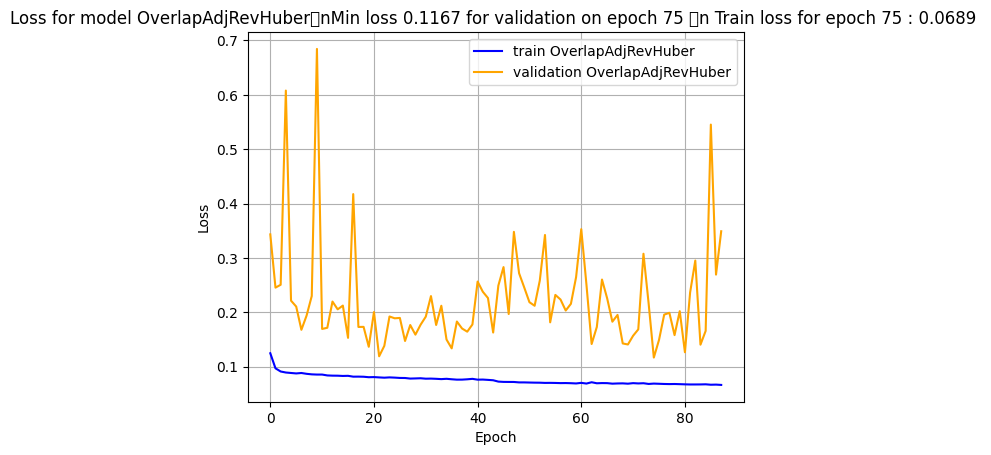

IndexError: list index out of range

In [23]:
#PLOT THE TRAINING CURVES OF MODELS
for i in range(2):#len(model_paths)):
    #PLOT LOSS PER MODEL
    min_loss = np.min(model_losses[i][1])
    min_loss_epoch = np.argmin(model_losses[i][1])
    plt.plot(model_losses[i][0], color='blue', label='train '+model_names[i])
    plt.plot(model_losses[i][1], color='orange', label='validation '+model_names[i])
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss for model {}⧵nMin loss {:.4f} for validation on epoch {} ⧵n Train loss for epoch {} : {:.4f} ".format(model_names[i], min_loss, min_loss_epoch+1, min_loss_epoch+1, model_losses[i][0][min_loss_epoch]))
    plt.grid()
    plt.legend()
    plt.show()
    
    #PLOT R^2 PER MODEL
    max_r2 = np.max(model_r2[i][1])
    max_r2_epoch = np.argmax(model_r2[i][1])
    plt.plot(np.array(model_r2[i][0]).clip(-1, 1), color='blue', label='train '+model_names[i])
    plt.plot(np.array(model_r2[i][1]).clip(-1, 1), color='orange', label='validation '+model_names[i])
    plt.xlabel("Epoch")
    plt.ylabel("R^2")
    plt.title("R^2 for model {}⧵n Max R^2 {:.4f} for validation on epoch {} ⧵n Train R^2 for epoch {} : {:.4f} ".format(model_names[i], max_r2, max_r2_epoch+1, max_r2_epoch+1, model_r2[i][0][max_r2_epoch]))
    plt.grid()
    plt.legend()
    plt.show()

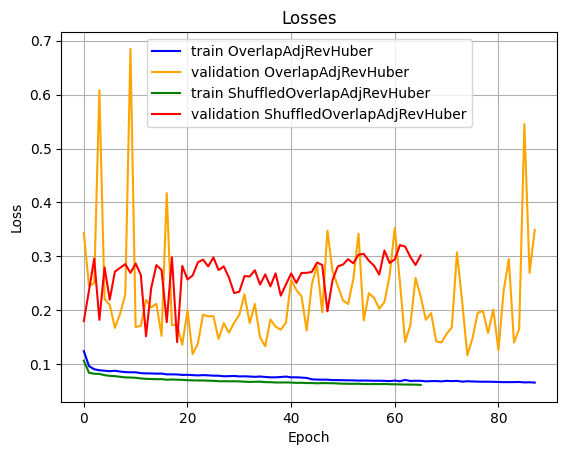

IndexError: list index out of range

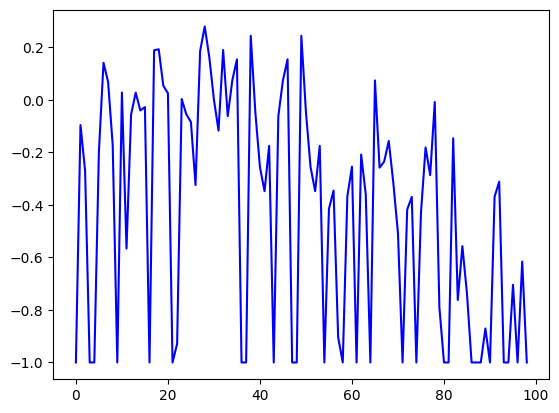

In [24]:
#PLOT THE TRAINING CURVES OF MODELS
colors_arr = [['blue', 'orange'], ['green', 'red']]

for i in range(2):#len(model_paths)):
    #PLOT LOSS PER MODEL
    plt.plot(model_losses[i][0], color=colors_arr[i][0], label='train '+model_names[i])
    plt.plot(model_losses[i][1], color=colors_arr[i][1], label='validation '+model_names[i])
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
plt.title("Losses")
plt.grid()
plt.legend()
plt.show()

for i in range(2):#len(model_paths)):
    #PLOT R^2 PER MODEL
    plt.plot(np.array(model_r2[i][0]).clip(-1, 1), color=colors_arr[i][0], label='train '+model_names[i])
    plt.plot(np.array(model_r2[i][1]).clip(-1, 1), color=colors_arr[i][1], label='validation '+model_names[i])
    plt.xlabel("Epoch")
    plt.ylabel("R^2")
plt.title("R^2")
plt.grid()
plt.legend()
plt.show()

In [25]:
#LOAD THE MODELS

models = []
for index in range(len(model_paths)):
    model_temp = tf.keras.models.load_model(model_paths[index], custom_objects={'RevHub_loss':RevHub_loss, 'combined_loss':combined_loss, 'volume_loss_difference':volume_loss_difference})
    models.append(model_temp)

In [26]:
#LOAD FILENAMES FOR TRAIN DATASET
filenames_train_dict = {}
for i in range(train_thres):
    material = directoriesProfilometer[i].split("/")[-1]
    filenames_temp = list(sorted(listdir(dataDirectory + directoriesProfilometer[i])))
    filenames_temp = [filenames_temp[ind_temp] for ind_temp in range(len(filenames_temp)) if dataDirectory+directoriesProfilometer[i]+'/'+filenames_temp[ind_temp] not in not_to_use]
    before_temp = [dataDirectory+directoriesProfilometer[i]+'/'+filenames_temp[j] for j in range(len(filenames_temp))]
    after_temp = [before_temp[j].replace('before', 'after') for j in range(len(before_temp))]
    heatmap_temp = [(after_temp[j].replace('profilometer', 'rawdata')).replace('png', 'csv') for j in range(len(after_temp))]
    filenames_train_dict[material]= {"prof":before_temp, "heat": heatmap_temp}

In [27]:
#LOAD FILENAMES FOR VALIDATION DATASET
filenames_val_dict = {}
for i in range(train_thres, val_thres):
    material = directoriesProfilometer[i].split("/")[-1]
    filenames_temp = list(sorted(listdir(dataDirectory + directoriesProfilometer[i])))
    filenames_temp = [filenames_temp[ind_temp] for ind_temp in range(len(filenames_temp)) if dataDirectory+directoriesProfilometer[i]+'/'+filenames_temp[ind_temp] not in not_to_use]
    before_temp = [dataDirectory+directoriesProfilometer[i]+'/'+filenames_temp[j] for j in range(len(filenames_temp))]
    after_temp = [before_temp[j].replace('before', 'after') for j in range(len(before_temp))]
    heatmap_temp = [(after_temp[j].replace('profilometer', 'rawdata')).replace('png', 'csv') for j in range(len(after_temp))]
    filenames_val_dict[material]= {"prof":before_temp, "heat": heatmap_temp}

In [28]:
#LOAD FILENAMES FOR TEST DATASET
filenames_test_dict = {}
for i in range(val_thres, len(directoriesProfilometer)):
    material_temp = directoriesProfilometer[i].split("/")[-1]
    filenames_temp = list(sorted(listdir(dataDirectory + directoriesProfilometer[i])))
    filenames_temp = [filenames_temp[ind_temp] for ind_temp in range(len(filenames_temp)) if dataDirectory+directoriesProfilometer[i]+'/'+filenames_temp[ind_temp] not in not_to_use]
    before_temp = [dataDirectory+directoriesProfilometer[i]+'/'+filenames_temp[j] for j in range(len(filenames_temp))]
    after_temp = [before_temp[j].replace('before', 'after') for j in range(len(before_temp))]
    heatmap_temp = [(after_temp[j].replace('profilometer', 'rawdata')).replace('png', 'csv') for j in range(len(after_temp))]
    filenames_test_dict[material_temp]= {"prof":before_temp, "heat": heatmap_temp}

In [34]:
fnames_test = []
for f in directoriesProfilometer[val_thres:]:
    for j in range(4):
        fnames_test.append(dataDirectory+"/"+f +"/{}.png".format(j+1))

In [35]:
fnames_test

['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/1.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/2.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/4.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/1.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/2.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/4.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/1.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//202

In [36]:
fnames_val = []
for f in directoriesProfilometer[train_thres:val_thres]:
    for j in range(4):
        fnames_val.append(dataDirectory+"/"+f +"/{}.png".format(j+1))

In [37]:
fnames_val

['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/1.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/2.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/4.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/1.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/2.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/4.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-8/1.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/

In [38]:
fnames_train = []
for f in directoriesProfilometer[:train_thres]:
    for j in range(4):
        fnames_train.append(dataDirectory+"/"+f +"/{}.png".format(j+1))

In [39]:
fnames_train

['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/1.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/2.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/4.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/1.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/2.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/4.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-5/1.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//202

In [31]:
(51+17+18)*4

344

In [28]:
len(filenames_val_dict.keys())

17

In [29]:
len(filenames_train_dict.keys())

51

In [30]:
len(c1)


344

In [47]:
c1_dict = {}
c2_dict = {}
fnames_test = []
for i in range(len(orig_directories_profilometer)):
    for j in range(4):
        c1_dict[dataDirectory+"/"+orig_directories_profilometer[i]+"/{}.png".format(j+1)] = c1[i*4+j]
        c2_dict[dataDirectory+"/"+orig_directories_profilometer[i]+"/{}.png".format(j+1)] = c2[i*4+j]
        fnames_test.append(dataDirectory+"/"+orig_directories_profilometer[i]+"/{}.png".format(j+1))

In [49]:
c1_dict

{'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/1.png': (965,
  950),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/2.png': (990,
  925),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/3.png': (955,
  960),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/4.png': (1045,
  930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/1.png': (935,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/2.png': (965,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/3.png': (1010,
  825),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/4.png': (980,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation

In [41]:
fnames_test

['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-5/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-11/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-4/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-12/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-7/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-11/3.png',
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//

In [27]:
#LOAD FILENAMES FOR NEW DATASET
filenames_new_dict = {}
for i in range(len(directoriesScannerNew)):
    material_temp = directoriesScannerNew[i].split("/")[-1]
    print("data dir is {}, scanner current dir: {}, together: {}".format(dataDirectory, directoriesScannerNew[i], dataDirectory + directoriesScannerNew[i]))
    filenames_temp = list(sorted(listdir(dataDirectory + directoriesScannerNew[i])))
    filenames_temp = [filenames_temp[ind_temp] for ind_temp in range(len(filenames_temp)) if dataDirectory+directoriesScannerNew[i]+'/'+filenames_temp[ind_temp] not in not_to_use and (dataDirectory+directoriesScannerNew[i]+'/'+filenames_temp[ind_temp])[-4:]=='tiff']
    before_temp = [dataDirectory+directoriesScannerNew[i]+'/'+filenames_temp[j] for j in range(len(filenames_temp))]
    
    filenames_new_dict[material_temp]= {"scanner":before_temp}

data dir is /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics, scanner current dir: /20230210/scanner/before/3-6, together: /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-6


FileNotFoundError: [Errno 2] No such file or directory: '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-6'

In [ ]:
#PROCESS SAMPLES OF THE TRAIN DATASET
train_metrics = eval_dataset(filenames_train_dict)

train_materials = list(filenames_train_dict.keys())

Shape of orig_img:  (1340, 1340, 3)
Shape of mask_supertemp:  (1340, 1340)
Shape od norm_heat:  (1340, 1340, 1)
3/3 [==============================] - 10s 3s/step
For model 0 and sample /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-1/1.png
Shape of pred_imgs[-1]:  (1340, 1340)


In [ ]:
#PLOT THE EVALUATION OF THE TRAIN DATASET
import matplotlib
matplotlib.use('AGG')
maes_train, rel_maes_train, vol_loss_gt_train, vol_losses_train, r2_train = plot_all_evaluation(train_metrics, "Train")
plt.show()

In [39]:
#TRAIN - ANALYSE PERFORMANCE ON THE "BAD" OUTLIERS
train_bad_prof_filenames = ["/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/4.png"]#, "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-3/3.png", "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-3/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-1/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-4/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-3-4/2.png"]
train_bad_heat_filenames = [((train_bad_prof_filenames[file_ind].replace('before', 'after')).replace('profilometer', 'rawdata')).replace('png', 'csv') for file_ind in range(len(train_bad_prof_filenames))]

for file_ind in range(len(train_bad_prof_filenames)):
    maes, rel_maes, r2s, vol_losses, vol_loss_gt =  process_sample(train_bad_prof_filenames[file_ind], train_bad_heat_filenames[file_ind], models, verbose=1)

4/4 [==============================] - 10s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/1.png is 0.06634263447570762
4/4 [==============================] - 10s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/2.png is 0.056213514300132716
4/4 [==============================] - 10s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/3.png is 0.06752648266604919
4/4 [==============================] - 10s 2s/step


/var/folders/rh/wqjw407133jfhj_bhjtl3tgj23ky7h/T/ipykernel_98135/1411179769.py:17: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(nrows=1, ncols=len(preds)+2, figsize=(18, 9))
/var/folders/rh/wqjw407133jfhj_bhjtl3tgj23ky7h/T/ipykernel_98135/4220943530.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/4.png is 0.05109674010016418


In [40]:
#TRAIN - ANALYSE PERFORMANCE ON THE "OK" OUTLIERS
train_ok_prof_filenames = ["/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-1/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-1/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-1/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-1/4.png"]#, "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/4.png", "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-3/3.png", "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-3/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-1/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-4/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-3-4/2.png"]
train_ok_heat_filenames = [((train_ok_prof_filenames[file_ind].replace('before', 'after')).replace('profilometer', 'rawdata')).replace('png', 'csv') for file_ind in range(len(train_ok_prof_filenames))]

for file_ind in range(len(train_ok_prof_filenames)):
    maes, rel_maes, r2s, vol_losses, vol_loss_gt =  process_sample(train_ok_prof_filenames[file_ind], train_ok_heat_filenames[file_ind], models, verbose=1)

4/4 [==============================] - 9s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-1/1.png is 0.3312464541688892
4/4 [==============================] - 9s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-1/2.png is 0.29772596168833726
4/4 [==============================] - 9s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-1/3.png is 0.320576011691073
4/4 [==============================] - 9s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-1/4.png is 0.3436080594323782


In [41]:
#TRAIN - ANALYSE PERFORMANCE ON THE "BEST" OUTLIERS
train_best_prof_filenames = ["/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-11/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-11/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-11/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-11/4.png"]#, "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-2/4.png", "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-3/3.png", "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-3/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-1/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220617/profilometer/before/4-1-4/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-3-4/2.png"]
train_best_heat_filenames = [((train_best_prof_filenames[file_ind].replace('before', 'after')).replace('profilometer', 'rawdata')).replace('png', 'csv') for file_ind in range(len(train_best_prof_filenames))]

for file_ind in range(len(train_best_prof_filenames)):
    maes, rel_maes, r2s, vol_losses, vol_loss_gt =  process_sample(train_best_prof_filenames[file_ind], train_best_heat_filenames[file_ind], models, verbose=1)

4/4 [==============================] - 9s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-11/1.png is 0.42600955666559925
4/4 [==============================] - 9s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-11/2.png is 0.4213780932897977
4/4 [==============================] - 9s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-11/3.png is 0.44630657218193803
4/4 [==============================] - 9s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-11/4.png is 0.41308775652768953


In [42]:
#PROCESS SAMPLES OF THE VALIDATION DATASET

val_metrics = eval_dataset(filenames_val_dict)
val_materials = list(filenames_val_dict.keys())

4/4 [==============================] - 9s 2s/step
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/1.png is 0.4106941312325064
Processing file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/1.png 
4/4 [==============================] - 9s 2s/step
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/2.png is 0.42490515931386347
Processing file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/2.png 
4/4 [==============================] - 10s 2s/step
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/3.png is 0.4449165281847034
Processing file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/3.png 
4/4 [==============================] - 10s 2s/step
Ncc for file /Users/anna.lisitsyna/Documents/Co

4/4 [==============================] - 9s 2s/step
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-7/1.png is 0.42098158435529465
Processing file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-7/1.png 
4/4 [==============================] - 9s 2s/step
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-7/2.png is 0.3050421461295916
Processing file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-7/2.png 
4/4 [==============================] - 9s 2s/step
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-7/3.png is 0.36161720663132163
Processing file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-7/3.png 
4/4 [==============================] - 9s 2s/step
Ncc for file /Users/anna.lisitsyna/Documents/Cor

In [43]:
val_metrics

{'4-5-1': {'fname': ['4-5-1/1', '4-5-1/2', '4-5-1/3', '4-5-1/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-5-1/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-5-1/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-5-1/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-5-1/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/b

In [44]:
metrics = val_metrics

vol_loss_gt_val = []
vol_losses_val = []
filenames_val = []

#SAVE ALL METRICS IN THE RIGHT FORMAT FOR TABLE
for m in metrics.keys():
    filenames_prof_temp = list(metrics[m]['metric_vals'].keys())
    #LOOK AT EACH SAMPLE FOR ONE MATERIAL
    for j in range(len(filenames_prof_temp)):
        prof_filename = filenames_prof_temp[j]

        if prof_filename not in not_to_use:
            if len(list(metrics[m]['metric_vals'][prof_filename].keys()))>0:
                vol_losses_val.append(metrics[m]['metric_vals'][prof_filename]['vol_loss'])
                vol_loss_gt_val.append(metrics[m]['metric_vals'][prof_filename]['vol_loss_gt'])
                filenames_val.append(prof_filename.split('/')[-2]+"/"+prof_filename.split('/')[-1][:-4])

In [45]:
metrics = train_metrics

vol_loss_gt_train = []
vol_losses_train = []
filenames_train = []

#SAVE ALL METRICS IN THE RIGHT FORMAT FOR TABLE
for m in metrics.keys():
    filenames_prof_temp = list(metrics[m]['metric_vals'].keys())
    #LOOK AT EACH SAMPLE FOR ONE MATERIAL
    for j in range(len(filenames_prof_temp)):
        prof_filename = filenames_prof_temp[j]

        if prof_filename not in not_to_use:
            if len(list(metrics[m]['metric_vals'][prof_filename].keys()))>0:
                vol_losses_train.append(metrics[m]['metric_vals'][prof_filename]['vol_loss'])
                vol_loss_gt_train.append(metrics[m]['metric_vals'][prof_filename]['vol_loss_gt'])
                filenames_train.append(prof_filename.split('/')[-2]+"/"+prof_filename.split('/')[-1][:-4])

In [46]:
metrics = test_metrics

vol_loss_gt_test = []
vol_losses_test = []
filenames_test = []

#SAVE ALL METRICS IN THE RIGHT FORMAT FOR TABLE
for m in metrics.keys():
    filenames_prof_temp = list(metrics[m]['metric_vals'].keys())
    #LOOK AT EACH SAMPLE FOR ONE MATERIAL
    for j in range(len(filenames_prof_temp)):
        prof_filename = filenames_prof_temp[j]

        if prof_filename not in not_to_use:
            if len(list(metrics[m]['metric_vals'][prof_filename].keys()))>0:
                vol_losses_test.append(metrics[m]['metric_vals'][prof_filename]['vol_loss'])
                vol_loss_gt_test.append(metrics[m]['metric_vals'][prof_filename]['vol_loss_gt'])
                filenames_test.append(prof_filename.split('/')[-2]+"/"+prof_filename.split('/')[-1][:-4])

NameError: name 'test_metrics' is not defined

In [ ]:
vol_losses_gt = vol_loss_gt_train+vol_loss_gt_val+vol_loss_gt_test
vol_losses_pred = np.concatenate((np.array(vol_losses_train)[:, 1], np.array(vol_losses_val)[:, 1], np.array(vol_losses_test)[:, 1]))
filenames = filenames_train+filenames_val+filenames_test
split = ['train' for i in range(len(filenames_train))]+['validation' for i in range(len(filenames_val))]+['test' for i in range(len(filenames_test))]

filenames_numbers = [filenames[i].split('/')[-1] for i in range(len(filenames))]
filenames_compound = [filenames[i].split('/')[0] for i in range(len(filenames))]
#split = ['validation' for i in range(len(filenames))]
diff_abs = [abs(vol_losses_pred[i]-vol_losses_gt[i]) for i in range(len(filenames))]
diff_rel = [abs(vol_losses_pred[i]-vol_losses_gt[i])/vol_losses_gt[i] for i in range(len(filenames))]

import pandas as pd
#PLOT THE TABLE
rows = ["Compound number", 'Sample number', 'Split', 'Volume loss predicted', 'Volume loss from GT', 'Absolute diff', 'Relative diff']
metrics_dict = {}
for sample_index in range(len(filenames_compound)):
    metrics_dict[sample_index] = [filenames_compound[sample_index], filenames_numbers[sample_index], split[sample_index], vol_losses_pred[sample_index]/2, vol_losses_gt[sample_index]/2, diff_abs[sample_index]/2, diff_rel[sample_index]]
evaluation_data  = pd.DataFrame(data=metrics_dict, index=rows).transpose()

In [ ]:
#evaluation_data.to_csv('eval_data.csv')
evaluation_data.to_excel('eval_data.xlsx')

In [47]:
#PLOT THE EVALUATION OF THE VALIDATION DATASET
maes_val, rel_maes_val, vol_loss_gt_val, vol_losses_val, r2_val = plot_all_evaluation(val_metrics, "Validation")

In [48]:
#VALIDATION - ANALYSE PERFORMANCE ON THE "BAD" OUTLIERS
val_bad_prof_filenames = ["/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/1.png"]#, "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/2.png", "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-4/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-4/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-4/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/2.png"]
val_bad_heat_filenames = [((val_bad_prof_filenames[file_ind].replace('before', 'after')).replace('profilometer', 'rawdata')).replace('png', 'csv') for file_ind in range(len(val_bad_prof_filenames))]

for file_ind in range(len(val_bad_prof_filenames)):
    try:
        maes, rel_maes, r2s, vol_losses, vol_loss_gt =  process_sample(val_bad_prof_filenames[file_ind], val_bad_heat_filenames[file_ind], models, verbose=1)
    except Exception as e:
        print("Problem with file {} is {}".format(val_bad_prof_filenames[file_ind], e))

4/4 [==============================] - 7s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/4.png is 0.2454666472882741
4/4 [==============================] - 7s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/3.png is 0.25430834521759066
4/4 [==============================] - 7s 2s/step


...

(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/2.png is 0.23140674310980205
4/4 [==============================] - 7s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/4.png is 0.2454666472882741
4/4 [==============================] - 8s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/1.png is 0.2512447269521202


In [49]:
#VALIDATION - ANALYSE PERFORMANCE ON THE "OK" OUTLIERS
val_ok_prof_filenames = ["/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-6/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-6/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-6/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-6/4.png"]#, "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/3.png", "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/2.png", "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-4/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-4/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-4/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/2.png"]
val_ok_heat_filenames = [((val_ok_prof_filenames[file_ind].replace('before', 'after')).replace('profilometer', 'rawdata')).replace('png', 'csv') for file_ind in range(len(val_ok_prof_filenames))]

for file_ind in range(len(val_ok_prof_filenames)):
    maes, rel_maes, r2s, vol_losses, vol_loss_gt =  process_sample(val_ok_prof_filenames[file_ind], val_ok_heat_filenames[file_ind], models, verbose=1)

4/4 [==============================] - 8s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-6/1.png is 0.3976352684191778
4/4 [==============================] - 8s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-6/2.png is 0.4434866030187571
4/4 [==============================] - 9s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-6/3.png is 0.4390161071536816
4/4 [==============================] - 9s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-6/4.png is 0.4315804235302756


In [50]:
#VALIDATION - ANALYSE PERFORMANCE ON THE "BEST" OUTLIERS
val_best_prof_filenames = ["/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-8/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-8/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-8/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-8/4.png"]#, "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/3.png", "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/2.png", "Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-4/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-3/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-1/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-4/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-4/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-4/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-1/2.png"]
val_best_heat_filenames = [((val_best_prof_filenames[file_ind].replace('before', 'after')).replace('profilometer', 'rawdata')).replace('png', 'csv') for file_ind in range(len(val_best_prof_filenames))]

for file_ind in range(len(val_best_prof_filenames)):
    maes, rel_maes, r2s, vol_losses, vol_loss_gt =  process_sample(val_best_prof_filenames[file_ind], val_best_heat_filenames[file_ind], models, verbose=1)

4/4 [==============================] - 8s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-8/1.png is 0.46655049400326715
4/4 [==============================] - 7s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-8/2.png is 0.4599994934747428
4/4 [==============================] - 8s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-8/3.png is 0.4612496711728314
4/4 [==============================] - 6s 1s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1513)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-5-8/4.png is 0.3455768260806432


In [ ]:
#PROCESS SAMPLES OF THE TEST DATASET

test_metrics = eval_dataset(filenames_test_dict)
test_materials = list(filenames_test_dict.keys())

Shape of orig_img:  (1340, 1340, 3)
Shape of mask_supertemp:  (1340, 1340)
Shape od norm_heat:  (1340, 1340, 1)
3/3 [==============================] - 5s 1s/step
For model 0 and sample /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-3-8/1.png
Shape of pred_imgs[-1]:  (1340, 1340)


In [71]:
test_metrics['4-4-5']

KeyError: '4-4-5'

In [53]:
test_metrics_less = copy.deepcopy(test_metrics)
del test_metrics_less['2-5-10']
test_materials_less = list(test_metrics_less.keys())

In [54]:
#PLOT THE EVALUATION OF THE TEST DATASET
maes_test, rel_maes_test, vol_loss_gt_test, vol_losses_test, r2_test = plot_all_evaluation(test_metrics_less, "Test")

In [65]:
np.array(test_materials_less)[4*vol_losses_test[:, 1]>0.8]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 17 but corresponding boolean dimension is 48

In [68]:
vol_losses_test[:, 1]>0.8

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True, False, False, False, False, False, False,  True, False,
       False, False, False])

In [55]:
test_metrics_less

{'4-6-6': {'fname': ['4-6-6/1', '4-6-6/2', '4-6-6/3', '4-6-6/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-6/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-6/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-6/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-6/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/b

In [ ]:
#TEST - ANALYSE PERFORMANCE ON THE "BAD" OUTLIERS
test_bad_prof_filenames = ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-7/4.png', '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/3.png', '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/4.png', "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/4.png"]#, "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/3.png"]
test_bad_heat_filenames = [((test_bad_prof_filenames[file_ind].replace('before', 'after')).replace('profilometer', 'rawdata')).replace('png', 'csv') for file_ind in range(len(test_bad_prof_filenames))]

for file_ind in range(len(test_bad_prof_filenames)):
    maes, rel_maes, r2s, vol_losses, vol_loss_gt =  process_sample(test_bad_prof_filenames[file_ind], test_bad_heat_filenames[file_ind], models, verbose=1)

Shape of orig_img:  (1340, 1277, 3)
Shape of mask_supertemp:  (1340, 1340)
Shape od norm_heat:  (1340, 1340, 1)
2/2 [==============================] - 4s 2s/step
For model 0 and sample /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-7/4.png
Shape of pred_imgs[-1]:  (1340, 1340)


In [57]:
#TEST - ANALYSE PERFORMANCE ON THE "OK" OUTLIERS
test_ok_prof_filenames = ["/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/4.png"]#, "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/3.png"]
test_ok_heat_filenames = [((test_ok_prof_filenames[file_ind].replace('before', 'after')).replace('profilometer', 'rawdata')).replace('png', 'csv') for file_ind in range(len(test_ok_prof_filenames))]

for file_ind in range(len(test_ok_prof_filenames)):
    maes, rel_maes, r2s, vol_losses, vol_loss_gt =  process_sample(test_ok_prof_filenames[file_ind], test_ok_heat_filenames[file_ind], models, verbose=1)

4/4 [==============================] - 11s 3s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/1.png is 0.3789532886481969
4/4 [==============================] - 12s 3s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/2.png is 0.358695181276115
4/4 [==============================] - 11s 3s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/3.png is 0.3688962653191381
4/4 [==============================] - 11s 3s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/4.png is 0.35582359692127835


In [58]:
#TEST - ANALYSE PERFORMANCE ON THE "BEST" OUTLIERS
test_best_prof_filenames = ["/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-9/1.png"]#, "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-9/2.png"]#, "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/1.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/2.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/3.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/4.png", "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/3.png"]
test_best_heat_filenames = [((test_best_prof_filenames[file_ind].replace('before', 'after')).replace('profilometer', 'rawdata')).replace('png', 'csv') for file_ind in range(len(test_best_prof_filenames))]

for file_ind in range(len(test_best_prof_filenames)):
    maes, rel_maes, r2s, vol_losses, vol_loss_gt =  process_sample(test_best_prof_filenames[file_ind], test_best_heat_filenames[file_ind], models, verbose=1)

4/4 [==============================] - 11s 3s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1536, 1536)
Ncc for file /Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-9/1.png is 0.486223284298598


In [ ]:
#LOAD NEW UNSEEN DATASET

new_materials = list(filenames_new_dict.keys())
filenames_new_dict['3-6']['center'] = {key: [] for key in filenames_new_dict['3-6']['scanner']}
filenames_new_dict['3-7']['center'] = {key: [] for key in filenames_new_dict['3-7']['scanner']}
filenames_new_dict['3-1']['center'] = {key: [] for key in filenames_new_dict['3-1']['scanner']}
filenames_new_dict['3-2']['center'] = {key: [] for key in filenames_new_dict['3-2']['scanner']}
filenames_new_dict['3-3']['center'] = {key: [] for key in filenames_new_dict['3-3']['scanner']}
filenames_new_dict['3-4']['center'] = {key: [] for key in filenames_new_dict['3-4']['scanner']}

filenames_new_dict['3-6']['vol_loss_gt'] = {key: [] for key in filenames_new_dict['3-6']['scanner']}
filenames_new_dict['3-7']['vol_loss_gt'] = {key: None for key in filenames_new_dict['3-7']['scanner']}
filenames_new_dict['3-1']['vol_loss_gt'] = {key: [] for key in filenames_new_dict['3-1']['scanner']}
filenames_new_dict['3-2']['vol_loss_gt'] = {key: [] for key in filenames_new_dict['3-2']['scanner']}
filenames_new_dict['3-3']['vol_loss_gt'] = {key: [] for key in filenames_new_dict['3-3']['scanner']}
filenames_new_dict['3-4']['vol_loss_gt'] = {key: None for key in filenames_new_dict['3-4']['scanner']}

fnames_annotation = ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-6/3-6-1.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-6/3-6-2.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-6/3-6-3.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-6/3-6-4.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-6/3-6-5.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-6/3-6-6.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-1.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-10.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-11.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-12.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-2.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-3.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-4.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-5.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-6.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-7.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-8.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-9.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-1/3-1-1.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-1/3-1-2.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-1/3-1-3.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-1/3-1-4.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-1/3-1-5.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-1/3-1-6.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-1.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-10.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-11.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-12.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-2.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-3.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-4.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-5.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-6.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-7.tiff',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-4/3-4-8.tiff']

centers_annotation = [[[1975, 6010],[1975, 10540], [1975, 15050], [1975, 19600]],
[[1720, 6090], [1720, 10590], [1720, 15120], [1720, 19650]],
[[1720, 6130], [1760, 10630], [1770, 15150], [1770, 19650]],
[[2000, 6000], [2000, 10500], [2000, 15000], [1970, 19520]],
[[2070, 5880], [2010, 10400], [1950, 14900], [1875, 19410]],
[[2050, 5970], [1975, 10510], [1850, 14975], [1720, 19500]],
[[1940, 6290], [1910, 10840], [1890, 15320], [1900, 19840]],
[[1875, 5530], [1780, 9980], [1990, 14900], [1875, 19325]],
[[1910, 5630], [1960, 10250],  [1815, 14920], [1720, 19425]],
[[1930, 5840], [1850, 10270], [1650, 14970], [1725, 19460]],
[[1790, 6510], [1810, 11050], [1860, 15550], [1890, 20060]],
[[1870, 6420], [1820, 10960], [1800, 15460], [1800, 19960]],
[[1905, 6310], [1835, 10825], [1785, 15340], [1750, 19830]],
[[1890, 6150], [1835, 10710], [1800, 15230], [1760, 19730]],
[[1610, 6290], [1600, 10860], [1600, 15370], [1630, 19870]],
[[1660, 5850], [1680, 10500], [1740, 15060], [1900, 19570]],
[[1750, 5610], [1710, 10390], [1660, 14980], [1710, 19380]],
[[1640, 5600], [1810, 10210], [1630, 15030], [1580, 19440]],
[[1960, 6260], [2030, 10770], [2080, 15310], [2130, 19840]],
[[1990, 6250], [2040, 10740], [2060, 15260], [2090, 19800]],
[[1980, 6150], [1980, 10650], [1980, 15170], [1960, 19680]],
[[2025, 6075], [2020, 10570], [1990, 15070], [1960, 19590]],
[[2025, 6055], [1970, 10555], [1940, 15055], [1870, 19580]],
[[1905, 6270], [1900, 10790], [1850, 15270], [1820, 19800]],
[[1650, 5920], [1870, 10420], [1780, 15080], [1820, 19480]],
[[2070, 5900], [2070, 10400],[1900, 15280], [2115, 19920]],
[[2020, 6030], [2010, 10415], [1890, 14990], [1780, 19790]],
[[1950, 6120], [1990, 10630], [1970, 15210], [1940, 19880]],
[[1750, 6110], [1750, 10610], [1660, 15280] , [1770, 19850]],
[[1750, 6160], [1700, 10570], [1950, 15400], [1920, 19920]],
[[1900, 6280], [1920, 10720], [1810, 15450], [2060, 20140]],
[[1990, 6350], [1920, 10760], [1760, 15300], [1600, 20050]],
[[1990, 6530], [1970, 11060], [1820, 15600], [1660, 20220]],
[[1800, 6230], [1960, 10730], [1830, 15420], [1830, 19820]],
[[1865, 6120], [1855, 10610], [1750, 15310], [1850, 19910]]]

#vol_losses_annotation = [] #ToDo add them from the information we have

for file_ind in range(len(fnames_annotation)):
    material_temp = fnames_annotation[file_ind].split('/')[-2]
    filenames_new_dict[material_temp]['center'][fnames_annotation[file_ind]] = centers_annotation[file_ind]
    #filenames_new_dict[material_temp]['vol_loss_gt'][filename_temp] = vol_losses_annotation[file_ind]

rad = 1225
from skimage.transform import resize

In [ ]:
plot_unseen_sample_evaluation('/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20230210/scanner/before/3-7/3-7-4.tiff')

In [ ]:
#SAVE THE TABLE FOR EVALUATION RESULTS
import pandas as pd
#PLOT THE TABLE
rows = ['MAE train', 'Relative MAE train', 'Volume loss correlation train', 'MAE validation', 'Relative MAE validation', 'Volume loss correlation validation', 'MAE test', 'Relative MAE test', 'Volume loss correlation test']
metrics_dict = {}
for model_ind in range(len(models)):
    metrics_dict[model_descriptions[model_ind]] = ["{:.4f}+-{:.4f}".format(np.array(maes_train)[:, model_ind].mean(), np.array(maes_train)[:, model_ind].std()), "{:.4f}+-{:.4f}".format(np.array(rel_maes_train)[:, model_ind].mean(), np.array(rel_maes_train)[:, model_ind].std()), np.corrcoef(np.array(vol_losses_train)[:, model_ind], vol_loss_gt_train)[0, 1], "{:.4f}+-{:.4f}".format(np.array(maes_val)[:, model_ind].mean(), np.array(maes_val)[:, model_ind].std()), "{:.4f}+-{:.4f}".format(np.array(rel_maes_val)[:, model_ind].mean(), np.array(rel_maes_val)[:, model_ind].std()), np.corrcoef(np.array(vol_losses_val)[:, model_ind], vol_loss_gt_val)[0, 1], "{:.4f}+-{:.4f}".format(np.array(maes_test)[:, model_ind].mean(), np.array(maes_test)[:, model_ind].std()), "{:.4f}+-{:.4f}".format(np.array(rel_maes_test)[:, model_ind].mean(), np.array(rel_maes_test)[:, model_ind].std()), np.corrcoef(np.array(vol_losses_test)[:, model_ind], vol_loss_gt_test)[0, 1]]
pd.DataFrame(data=metrics_dict, index=rows).transpose()

In [ ]:
#load the original profilometer image
filename_temp = "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/profilometer/before/2-2-11/1.png"
res_img = resize_profilometer(filename_temp,resize_coeff=1)
masked = mask(res_img, c= (940, 845))
norm_img = norm_01(masked)

In [ ]:
patches_prof = patches(masked)

In [ ]:
plt.imshow(res_img)

In [ ]:
plt.imshow(masked)

In [ ]:
plt.imshow(patches_prof[30])

In [ ]:
#load the original profilometer image
filename_temp = "/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220823/rawdata/after/2-2-11/1.csv"
res_img = interp(pd.read_csv(filepath_or_buffer=filename_temp, skiprows=22,engine='python').to_numpy()[:1664, :1792],
                filename=filename_temp,resize_coeff=1)
clipped_img = res_img.clip(min=-0.03, max=0.01)
norm_img = norm_01(clipped_img)
masked = mask(norm_img, c= (945, 845))


In [ ]:
plt.imshow(res_img, cmap='gray')

In [ ]:
plt.imshow(clipped_img, cmap='gray')

In [ ]:
plt.imshow(norm_img, cmap='gray')

In [ ]:
plt.imshow(masked, cmap='gray')

In [ ]:
#annotation
i=0
filename_temp = filenames_scanner[i]

im = Image.open(filename_temp)
im = np.array(im)
#pad etc
#normalize
plt.imshow(im)
#add callback to show circle on clicking 
#add callback to show x, y on hovering
#save the coordinates to list 

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib qt 
%matplotlib inline

plt.rcParams["figure.figsize"] = [7.00, 3.50]
plt.rcParams["figure.autolayout"] = True

#rad = 

def mouse_event(event):
    #plt.
    print('x: {} and y: {}'.format(event.xdata, event.ydata))

fig = plt.figure()
cid = fig.canvas.mpl_connect('button_press_event', mouse_event)

x = np.linspace(-10, 10, 100)
y = np.sin(x)

plt.plot(x, y)

plt.show()

In [ ]:
import PyQt5

In [54]:
test_metrics_less = {'4-6-6': {'fname': ['4-6-6/1', '4-6-6/2', '4-6-6/3', '4-6-6/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-6/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-6/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-6/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-6/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/1.png': {'r2': [0.25617171791984483,
     0.21529371579060375],
    'mae': [0.09263310304091225, 0.08958343908578534],
    'rel_mae': [8.19013101862327, 7.7040065332870205],
    'vol_loss': [0.3191867842649431, 0.4359475099201261],
    'vol_loss_gt': 0.37269590611583847},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/2.png': {'r2': [0.14215931234520351,
     0.21605784122247296],
    'mae': [0.10048972026954976, 0.0918379005145946],
    'rel_mae': [8.823826986388992, 7.630322652624718],
    'vol_loss': [0.2974297470893154, 0.3938011297382081],
    'vol_loss_gt': 0.4573362348471916},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/3.png': {'r2': [0.2906417190307148,
     0.2740483736304625],
    'mae': [0.08656945334280461, 0.08475495434909891],
    'rel_mae': [6.108330553591888, 6.048071885592233],
    'vol_loss': [0.28215658109143243, 0.37484095087792707],
    'vol_loss_gt': 0.44080774415501944},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-6/4.png': {'r2': [0.28353613806775435,
     0.2972001513445933],
    'mae': [0.10023746499460623, 0.09094846985136144],
    'rel_mae': [8.960057785552937, 7.425800497138881],
    'vol_loss': [0.3748153936945807, 0.5188269474986199],
    'vol_loss_gt': 0.6558527844563096}}},
 '4-6-7': {'fname': ['4-6-7/1', '4-6-7/2', '4-6-7/3', '4-6-7/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-7/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-7/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-7/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-7/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/1.png': {'r2': [-0.021926294703905835,
     0.015181899740182025],
    'mae': [0.2447192558099964, 0.23929211918991336],
    'rel_mae': [7.544666219892646, 6.78150335284294],
    'vol_loss': [0.2580972865017749, 0.1955851362157637],
    'vol_loss_gt': 1.119223716424683},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/2.png': {'r2': [-0.015015156195455903,
     0.031254120837009736],
    'mae': [0.26415935890273173, 0.2540153113828022],
    'rel_mae': [5.5004987675448795, 5.1873491912960645],
    'vol_loss': [0.21520105540177606, 0.2548885912166945],
    'vol_loss_gt': 1.2565784985465067},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/3.png': {'r2': [0.006467118508830638,
     0.041934985010310455],
    'mae': [0.24986066303368898, 0.24836178900882358],
    'rel_mae': [9.272127874100851, 9.939356115794839],
    'vol_loss': [0.22925845356268845, 0.2827362393128358],
    'vol_loss_gt': 1.0155189195922747},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-7/4.png': {'r2': [-0.007611730992083565,
     0.02542366103932492],
    'mae': [0.3218734976690068, 0.31017782168373365],
    'rel_mae': [9.88696769017115, 8.401781887358851],
    'vol_loss': [0.184784884637409, 0.19688190691069585],
    'vol_loss_gt': 1.3350071454847319}}},
 '4-6-8': {'fname': ['4-6-8/1', '4-6-8/2', '4-6-8/3', '4-6-8/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-8/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-8/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-8/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-8/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/1.png': {'r2': [0.16520894213034532,
     0.12075996669709299],
    'mae': [0.05806753579175627, 0.0649848415826117],
    'rel_mae': [5.416297592549044, 6.702067864363516],
    'vol_loss': [0.2287101844429548, 0.364732250062157],
    'vol_loss_gt': 0.15587344750065635},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/2.png': {'r2': [0.1988684967913158,
     0.1403673720304286],
    'mae': [0.07068903325335271, 0.07362365176775809],
    'rel_mae': [7.195093372874295, 7.663475878662449],
    'vol_loss': [0.1845877584794454, 0.24785013970291653],
    'vol_loss_gt': 0.4768512418170231},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/3.png': {'r2': [-0.14919096214637295,
     0.0522986867238624],
    'mae': [0.08016266273093915, 0.07099132180838494],
    'rel_mae': [8.343992427382044, 7.482319433506571],
    'vol_loss': [0.16957827626902622, 0.2594449784035121],
    'vol_loss_gt': 0.4230875506602327},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-8/4.png': {'r2': [0.048180434780423775,
     0.25265330642735984],
    'mae': [0.054160834959053446, 0.04673541926728957],
    'rel_mae': [5.414569841832054, 4.77734758447253],
    'vol_loss': [0.18910800025223254, 0.32231359842163193],
    'vol_loss_gt': 0.33354313128009}}},
 '4-6-9': {'fname': ['4-6-9/1', '4-6-9/2', '4-6-9/3', '4-6-9/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-9/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-9/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-9/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-9/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/1.png': {'r2': [-0.32033401779955906,
     0.07860888789098563],
    'mae': [0.1674752593559377, 0.12553960797383867],
    'rel_mae': [18.201588357221066, 13.245797785370609],
    'vol_loss': [0.3969418394993438, 0.5831207309062358],
    'vol_loss_gt': 1.0680502973456791},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/2.png': {'r2': [-0.09816947705086165,
     0.05866552546690673],
    'mae': [0.17765787109031816, 0.14381010344943668],
    'rel_mae': [17.10162886216823, 12.72495048643416],
    'vol_loss': [0.39839354562230467, 0.6096812385043124],
    'vol_loss_gt': 1.1627622598074292},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/3.png': {'r2': [-0.35124132071787595,
     -0.027058244201628723],
    'mae': [0.16826462133050066, 0.12955082358696224],
    'rel_mae': [18.022657889921994, 12.902989414160992],
    'vol_loss': [0.35046917734294186, 0.5734982703287151],
    'vol_loss_gt': 1.0746258083913123},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-9/4.png': {'r2': [-0.256788066553705,
     0.00894862258311746],
    'mae': [0.17752379449177658, 0.13308408337057473],
    'rel_mae': [19.910678080023118, 13.119063320793426],
    'vol_loss': [0.38265706414182327, 0.6260522409236651],
    'vol_loss_gt': 1.1652847412440033}}},
 '4-6-10': {'fname': ['4-6-10/1', '4-6-10/2', '4-6-10/3', '4-6-10/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-10/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-10/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-10/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-10/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-10/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-10/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-10/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-10/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-10/1.png': {'r2': [-0.10864896849542927,
     0.17586798012238058],
    'mae': [0.11642407301264351, 0.09431592587615696],
    'rel_mae': [11.516490261675775, 8.733115691639435],
    'vol_loss': [0.41396934568856664, 0.5264399279095018],
    'vol_loss_gt': 0.7659040420571146},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-10/2.png': {'r2': [-0.05290592833523089,
     0.17901751957482015],
    'mae': [0.13675420872003935, 0.11379664189633712],
    'rel_mae': [10.169004943254462, 8.272528284824434],
    'vol_loss': [0.42078872772869075, 0.6531558266519059],
    'vol_loss_gt': 0.9221818187981811},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-10/3.png': {'r2': [-0.3209067997928825,
     0.12047513220347783],
    'mae': [0.1462448184248908, 0.10898632600782367],
    'rel_mae': [13.808760436999098, 9.700859325067954],
    'vol_loss': [0.32973002801117757, 0.536095426239178],
    'vol_loss_gt': 0.9462289410470126},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-10/4.png': {'r2': [0.10589419608238015,
     0.2507647979005857],
    'mae': [0.12467584775340547, 0.10608739008603349],
    'rel_mae': [9.34446250771485, 7.753291085718771],
    'vol_loss': [0.3880070003037466, 0.5421026418328537],
    'vol_loss_gt': 0.8659957168003846}}},
 '4-6-11': {'fname': ['4-6-11/1', '4-6-11/2', '4-6-11/3', '4-6-11/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-11/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-11/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-11/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-11/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-11/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-11/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-11/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-11/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-11/1.png': {'r2': [0.005272181516683183,
     0.1042044456596567],
    'mae': [0.07685344609230828, 0.07039519576576997],
    'rel_mae': [6.663153432529972, 5.999171325486239],
    'vol_loss': [0.1959198450032432, 0.22618583380721807],
    'vol_loss_gt': 0.40166482817752347},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-11/2.png': {'r2': [0.16710070961457502,
     0.24031350689342268],
    'mae': [0.06980042468856067, 0.06085820920951561],
    'rel_mae': [5.776398639834144, 4.846570632237794],
    'vol_loss': [0.25975179877312154, 0.280071471354769],
    'vol_loss_gt': 0.4215935875251089},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-11/3.png': {'r2': [0.0009445308565333432,
     -0.06063760899718518],
    'mae': [0.08185225117778673, 0.10654638436076848],
    'rel_mae': [7.27872952392213, 11.886506596963034],
    'vol_loss': [0.3308513906050533, 0.5359197482835891],
    'vol_loss_gt': 0.3483494432836913},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-11/4.png': {'r2': [0.1447147353903817,
     0.1833087611449008],
    'mae': [0.07452903734788514, 0.0638912569302623],
    'rel_mae': [7.487275692903342, 5.415513879091162],
    'vol_loss': [0.291219795895882, 0.24190235315092398],
    'vol_loss_gt': 0.4335085619777937}}},
 '4-6-12': {'fname': ['4-6-12/1', '4-6-12/2', '4-6-12/3', '4-6-12/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-12/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-12/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-12/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-12/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-12/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-12/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-12/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/rawdata/after/4-6-12/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-12/1.png': {'r2': [-0.027725724106315575,
     0.17835965552485245],
    'mae': [0.11602546067274698, 0.09362609477589931],
    'rel_mae': [8.929404429314511, 6.317397195430148],
    'vol_loss': [0.2563028351610375, 0.35499621531371833],
    'vol_loss_gt': 0.7005295344446147},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-12/2.png': {'r2': [0.10068287814467725,
     0.19405908180714915],
    'mae': [0.10377144208986815, 0.08634657443004995],
    'rel_mae': [9.137511111659503, 6.985592879514886],
    'vol_loss': [0.26866301771317697, 0.38248995684551074],
    'vol_loss_gt': 0.6533334727134628},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-12/3.png': {'r2': [0.05527650796631434,
     0.18046705784437855],
    'mae': [0.11506582987699417, 0.09440674205235806],
    'rel_mae': [8.96026132111271, 6.190449933026927],
    'vol_loss': [0.24862953409101818, 0.3577361349430635],
    'vol_loss_gt': 0.6977442439483335},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220719/profilometer/before/4-6-12/4.png': {'r2': [-0.044094803728086385,
     0.09055701189172405],
    'mae': [0.11243744896601295, 0.09996003747560048],
    'rel_mae': [7.697764568765623, 6.604077644307066],
    'vol_loss': [0.17902603318545854, 0.3052620642240584],
    'vol_loss_gt': 0.5651213364292326}}},
 '2-5-1': {'fname': ['2-5-1/1', '2-5-1/2'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-1/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-1/2.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-1/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-1/2.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-1/1.png': {'r2': [0.21969654972100938,
     0.13700806512891484],
    'mae': [0.060458188624979085, 0.06186150446245962],
    'rel_mae': [6.158538646422019, 6.890138247556081],
    'vol_loss': [0.31084679586516073, 0.4061574685642613],
    'vol_loss_gt': 0.2306195030450309},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-1/2.png': {}}},
 '2-5-2': {'fname': ['2-5-2/1', '2-5-2/3'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-2/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-2/3.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-2/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-2/3.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-2/1.png': {'r2': [0.2537534378265036,
     0.2559264724433461],
    'mae': [0.07130591975191242, 0.06693668404545779],
    'rel_mae': [6.665441300595126, 6.740660856878536],
    'vol_loss': [0.3622561000261479, 0.4934263561995644],
    'vol_loss_gt': 0.5150314002294338},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-2/3.png': {}}},
 '2-5-3': {'fname': ['2-5-3/1', '2-5-3/2', '2-5-3/3', '2-5-3/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-3/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-3/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-3/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-3/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-3/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-3/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-3/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-3/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-3/1.png': {'r2': [0.27348273775721166,
     0.22514560821065266],
    'mae': [0.07019437818990415, 0.07384806082492072],
    'rel_mae': [7.834348818273537, 8.40500559823361],
    'vol_loss': [0.19272687526687973, 0.2419378293997555],
    'vol_loss_gt': 0.11130933462521558},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-3/2.png': {'r2': [0.3175120385236674,
     0.3707897539556281],
    'mae': [0.06545691844191277, 0.06478897478172783],
    'rel_mae': [5.551344725412999, 5.869230695917491],
    'vol_loss': [0.294281984343497, 0.3902349588699998],
    'vol_loss_gt': 0.35859662037871115},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-3/3.png': {'r2': [-0.3876726439945053,
     -0.4323844595593038],
    'mae': [0.10039782476622928, 0.10497562585244073],
    'rel_mae': [6.109701216274543, 7.382500722921968],
    'vol_loss': [0.6074919726154657, 0.6570646781527708],
    'vol_loss_gt': 0.2753566609985026},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-3/4.png': {}}},
 '2-5-5': {'fname': ['2-5-5/1', '2-5-5/2', '2-5-5/3', '2-5-5/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-5/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-5/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-5/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-5/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/1.png': {'r2': [-0.40027549012872066,
     -0.06510645446301067],
    'mae': [0.2434821499484946, 0.19316400256634525],
    'rel_mae': [24.65773309718901, 27.374382795769826],
    'vol_loss': [0.8428166284811767, 0.6410435258730257],
    'vol_loss_gt': 0.5079878555257002},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/2.png': {'r2': [-0.12437717704853446,
     -0.10191728685673951],
    'mae': [0.22085015183710258, 0.24268718008310652],
    'rel_mae': [24.64965661959796, 36.48496528899372],
    'vol_loss': [0.5660005207884383, 0.6966401265646762],
    'vol_loss_gt': 0.4739621481783603},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/3.png': {'r2': [-0.20954422747863455,
     -0.09097963401397613],
    'mae': [0.3107664237036947, 0.2845513283248286],
    'rel_mae': [45.43362318122318, 39.95061264829608],
    'vol_loss': [0.9507429500217549, 0.876971790382914],
    'vol_loss_gt': 0.5514646059364458},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-5/4.png': {'r2': [-0.41929504121959993,
     -0.1543198874169025],
    'mae': [0.32707856514956524, 0.2726062956622558],
    'rel_mae': [61.89340066594994, 43.70655699300235],
    'vol_loss': [1.0879525767759244, 0.894933680936026],
    'vol_loss_gt': 0.6173474268751802}}},
 '2-5-6': {'fname': ['2-5-6/1', '2-5-6/2', '2-5-6/3', '2-5-6/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-6/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-6/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-6/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-6/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-6/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-6/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-6/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-6/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-6/1.png': {'r2': [0.2827509854491853,
     0.2985082301235812],
    'mae': [0.0787109059367247, 0.07842634204116808],
    'rel_mae': [5.80394839977697, 6.369031656514725],
    'vol_loss': [0.3501193476919928, 0.5347388361853674],
    'vol_loss_gt': 0.5039485243881454},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-6/2.png': {'r2': [0.4061322560655508,
     0.3229586805752813],
    'mae': [0.05910375019415068, 0.06569164877605928],
    'rel_mae': [5.299584159107133, 6.138787563496643],
    'vol_loss': [0.32349016508819683, 0.39696914468854194],
    'vol_loss_gt': 0.351634785876697},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-6/3.png': {'r2': [0.2923364683186692,
     0.26209093027102226],
    'mae': [0.0655789646907454, 0.07019411536675164],
    'rel_mae': [5.496728211732521, 7.015383667704825],
    'vol_loss': [0.39125305115323783, 0.5488243556304009],
    'vol_loss_gt': 0.4297532475306449},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-6/4.png': {'r2': [0.4129977825568446,
     0.34345961828868],
    'mae': [0.07330562310892928, 0.07381680667136695],
    'rel_mae': [5.862061322868751, 6.150669307024093],
    'vol_loss': [0.3568266189855529, 0.384749161874392],
    'vol_loss_gt': 0.43598283453293074}}},
 '2-5-7': {'fname': ['2-5-7/1', '2-5-7/2', '2-5-7/3', '2-5-7/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-7/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-7/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-7/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-7/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-7/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-7/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-7/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-7/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-7/1.png': {'r2': [0.2557187745250542,
     0.20539755407480187],
    'mae': [0.0693282854497032, 0.07348325587515622],
    'rel_mae': [5.516935305056178, 6.179054323921893],
    'vol_loss': [0.31013821444545264, 0.4037271588215814],
    'vol_loss_gt': 0.28504987837504725},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-7/2.png': {'r2': [0.22838289751277263,
     0.1708983223556737],
    'mae': [0.07305560622072806, 0.08044634899430127],
    'rel_mae': [5.600024722753078, 7.753594587602623],
    'vol_loss': [0.3650645778882911, 0.5505003804982743],
    'vol_loss_gt': 0.2893289016047098},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-7/3.png': {'r2': [-0.5863522188887973,
     -0.6016351378806335],
    'mae': [0.11913997080387535, 0.12728394796739198],
    'rel_mae': [5.806019850590386, 7.674422373214443],
    'vol_loss': [0.7693576598636624, 0.8607727221951279],
    'vol_loss_gt': 0.25526051111329945},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-7/4.png': {}}},
 '2-5-8': {'fname': ['2-5-8/1'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-8/1.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-8/1.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-8/1.png': {}}},
 '2-5-9': {'fname': ['2-5-9/2'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-9/2.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-9/2.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-9/2.png': {}}},
 '2-5-11': {'fname': ['2-5-11/1', '2-5-11/2', '2-5-11/3'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-11/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-11/2.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-11/3.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-11/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-11/2.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-11/3.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-11/1.png': {'r2': [-0.18486748133811082,
     -0.15252805085326981],
    'mae': [0.1242066879974036, 0.14583977500461226],
    'rel_mae': [10.872807458860812, 21.062248564432267],
    'vol_loss': [0.49876993934548636, 0.6732635035924532],
    'vol_loss_gt': 0.38402488096645915},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-11/2.png': {'r2': [-0.03802269585390072,
     0.007695556508227286],
    'mae': [0.11958772287456305, 0.1411300743969843],
    'rel_mae': [6.196822527879363, 12.315271063323477],
    'vol_loss': [0.33431937898385944, 0.5390164207507191],
    'vol_loss_gt': 0.5740641278349589},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-11/3.png': {}}},
 '2-5-12': {'fname': ['2-5-12/1', '2-5-12/3', '2-5-12/4'],
  'prof': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-12/1.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-12/3.png',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-12/4.png'],
  'heat': ['/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-12/1.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-12/3.csv',
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/rawdata/after/2-5-12/4.csv'],
  'metric_vals': {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-12/1.png': {'r2': [0.2657584902714709,
     0.21466411314106715],
    'mae': [0.07603775667951196, 0.08266341128263932],
    'rel_mae': [6.494451890620616, 8.825729121390285],
    'vol_loss': [0.45177510518896524, 0.6436400220958831],
    'vol_loss_gt': 0.421188911675379},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-12/3.png': {'r2': [0.3673333969827073,
     0.31735218443599256],
    'mae': [0.08264378720569637, 0.08734492754351009],
    'rel_mae': [8.15660864987732, 9.144911836621562],
    'vol_loss': [0.4303536092795471, 0.5699113564183241],
    'vol_loss_gt': 0.4047290706031607},
   '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics/20220906/profilometer/before/2-5-12/4.png': {}}}}

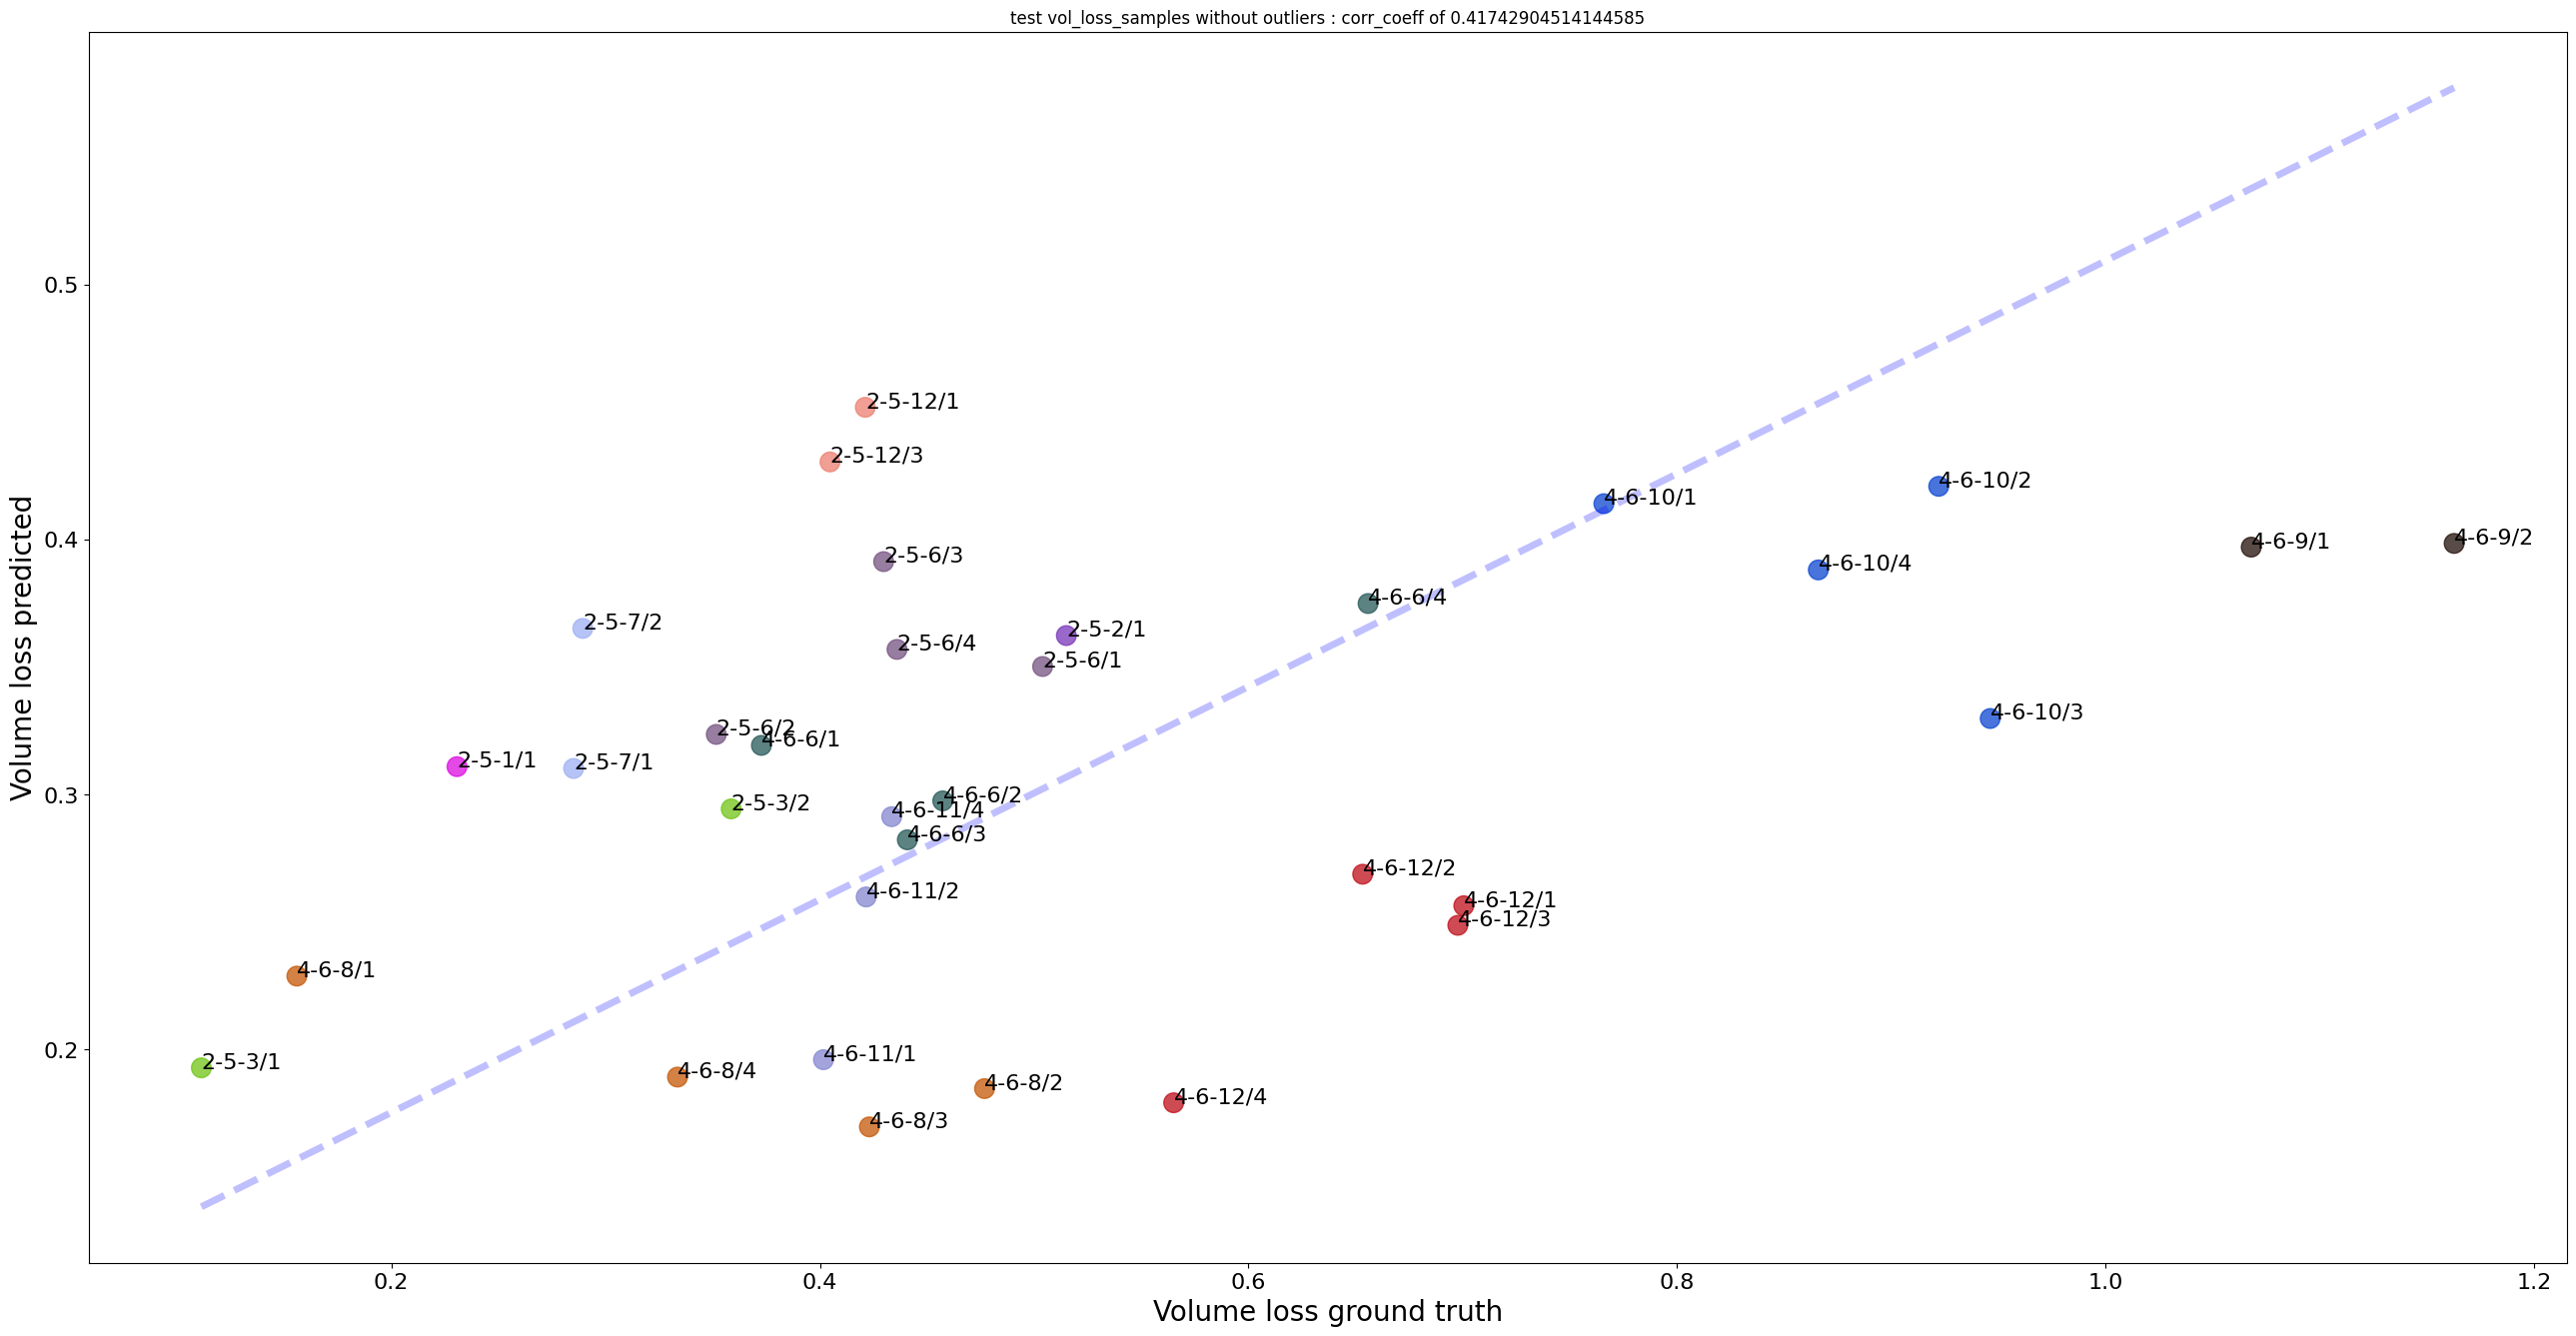

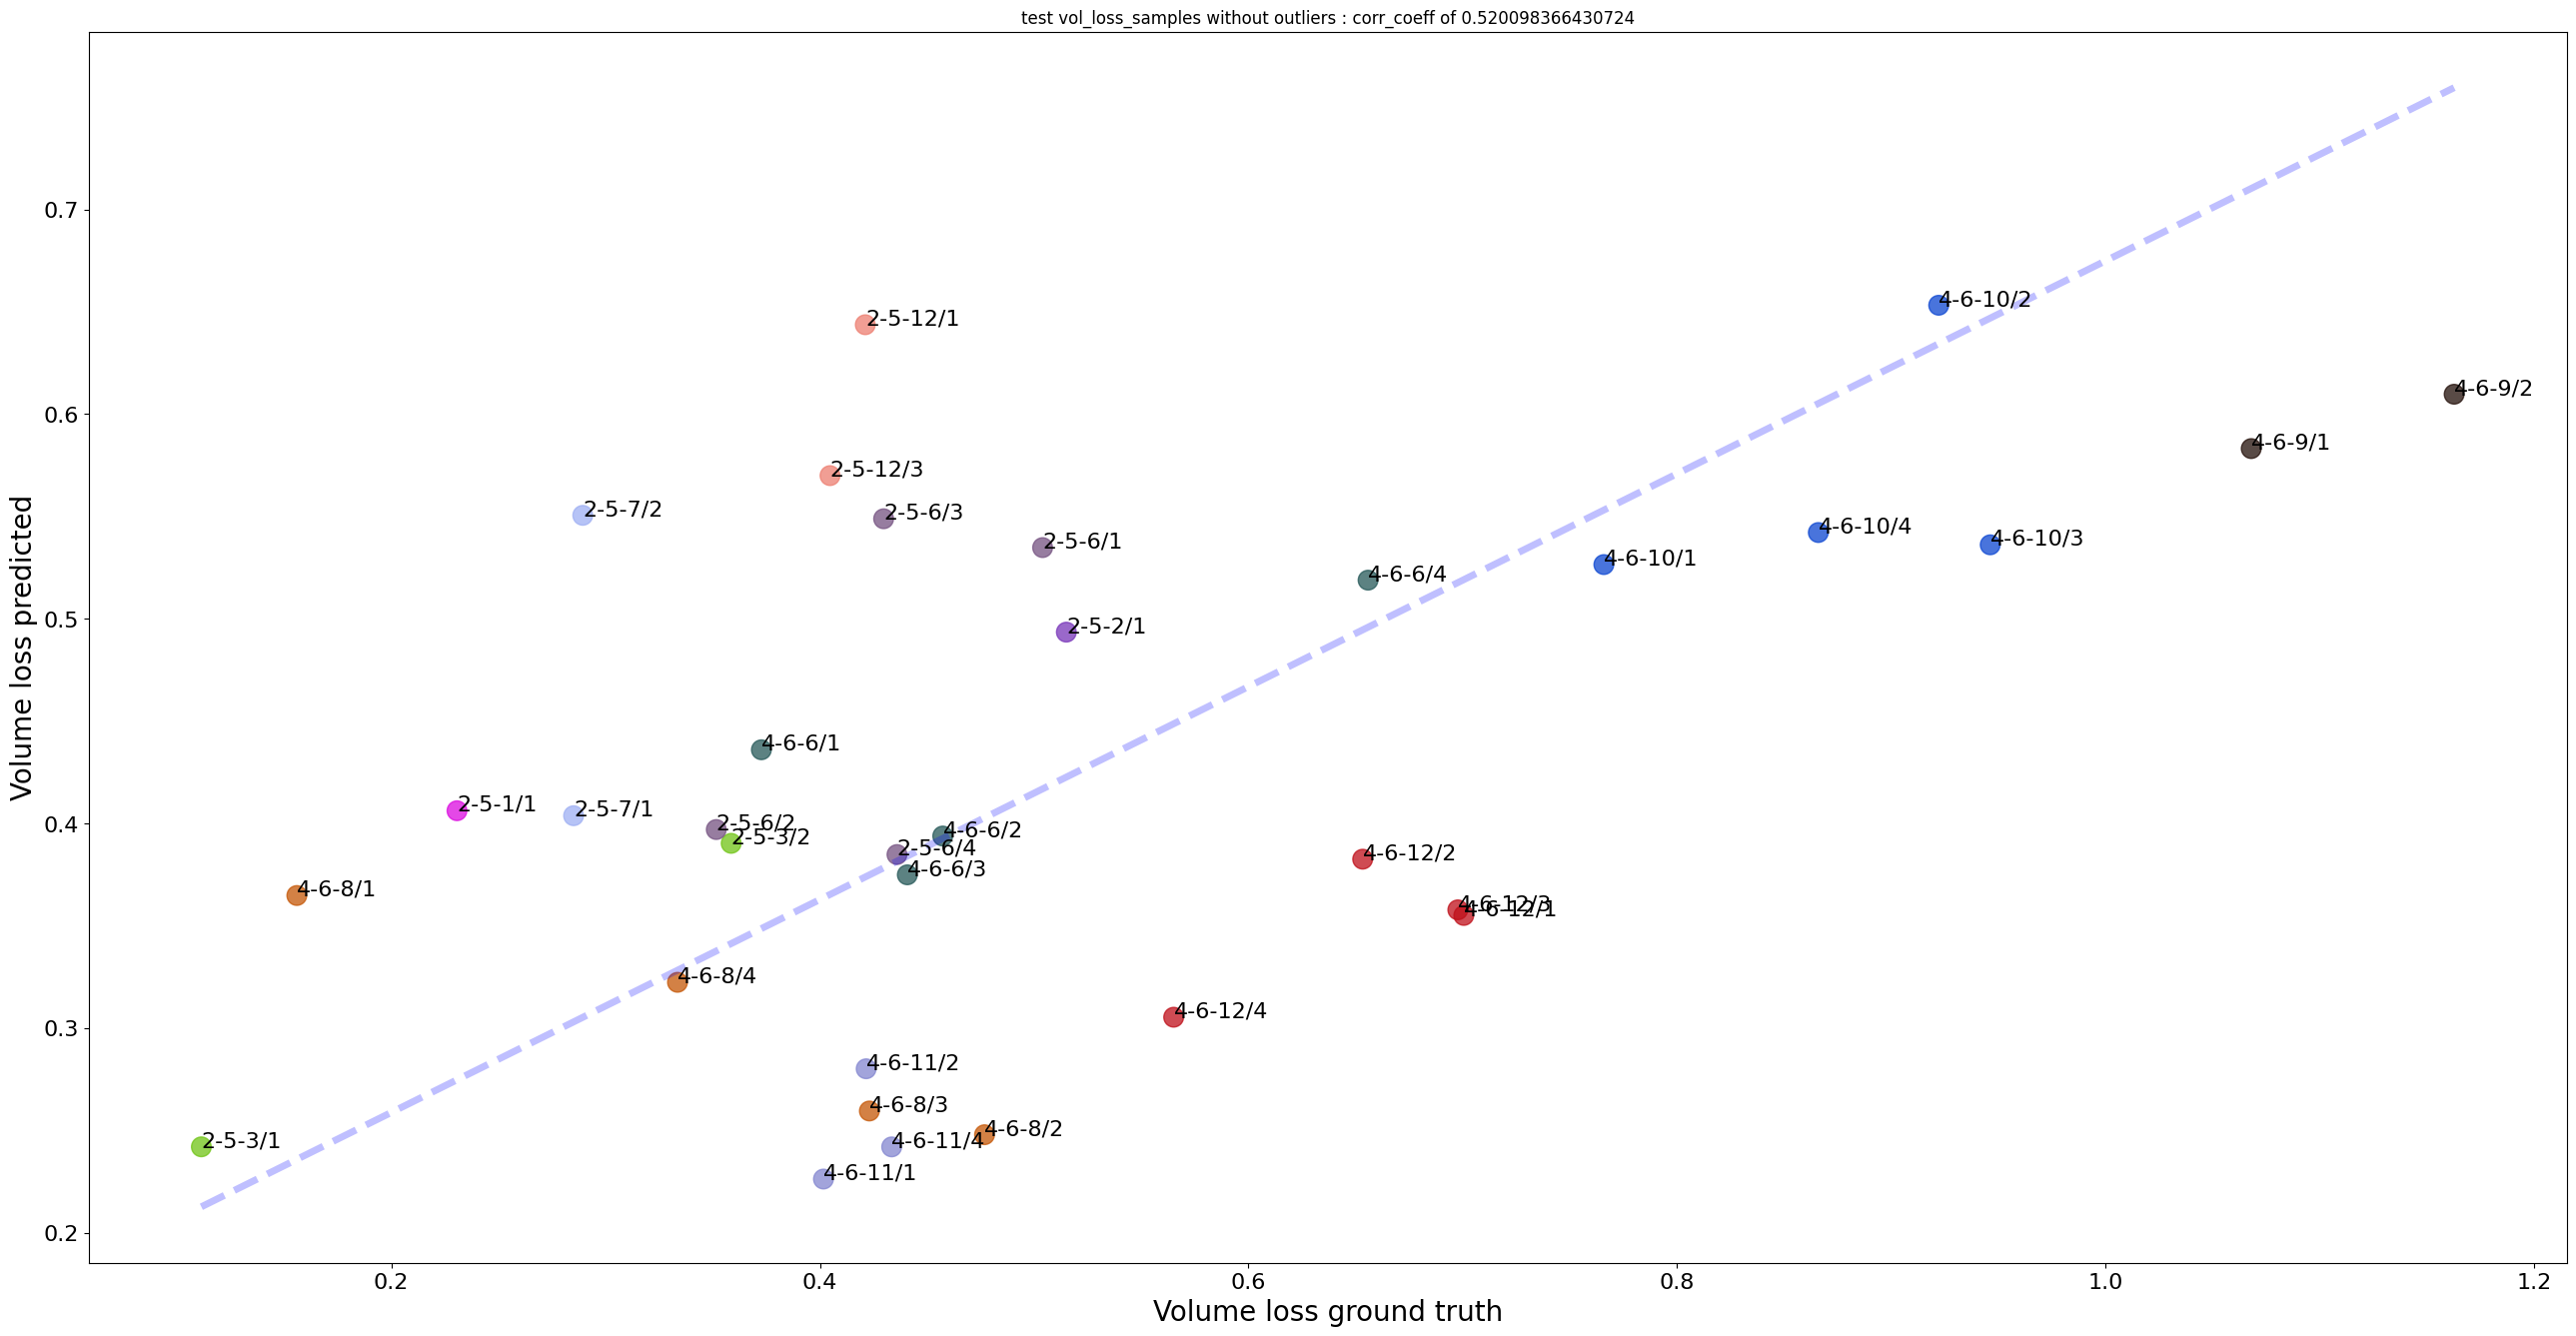

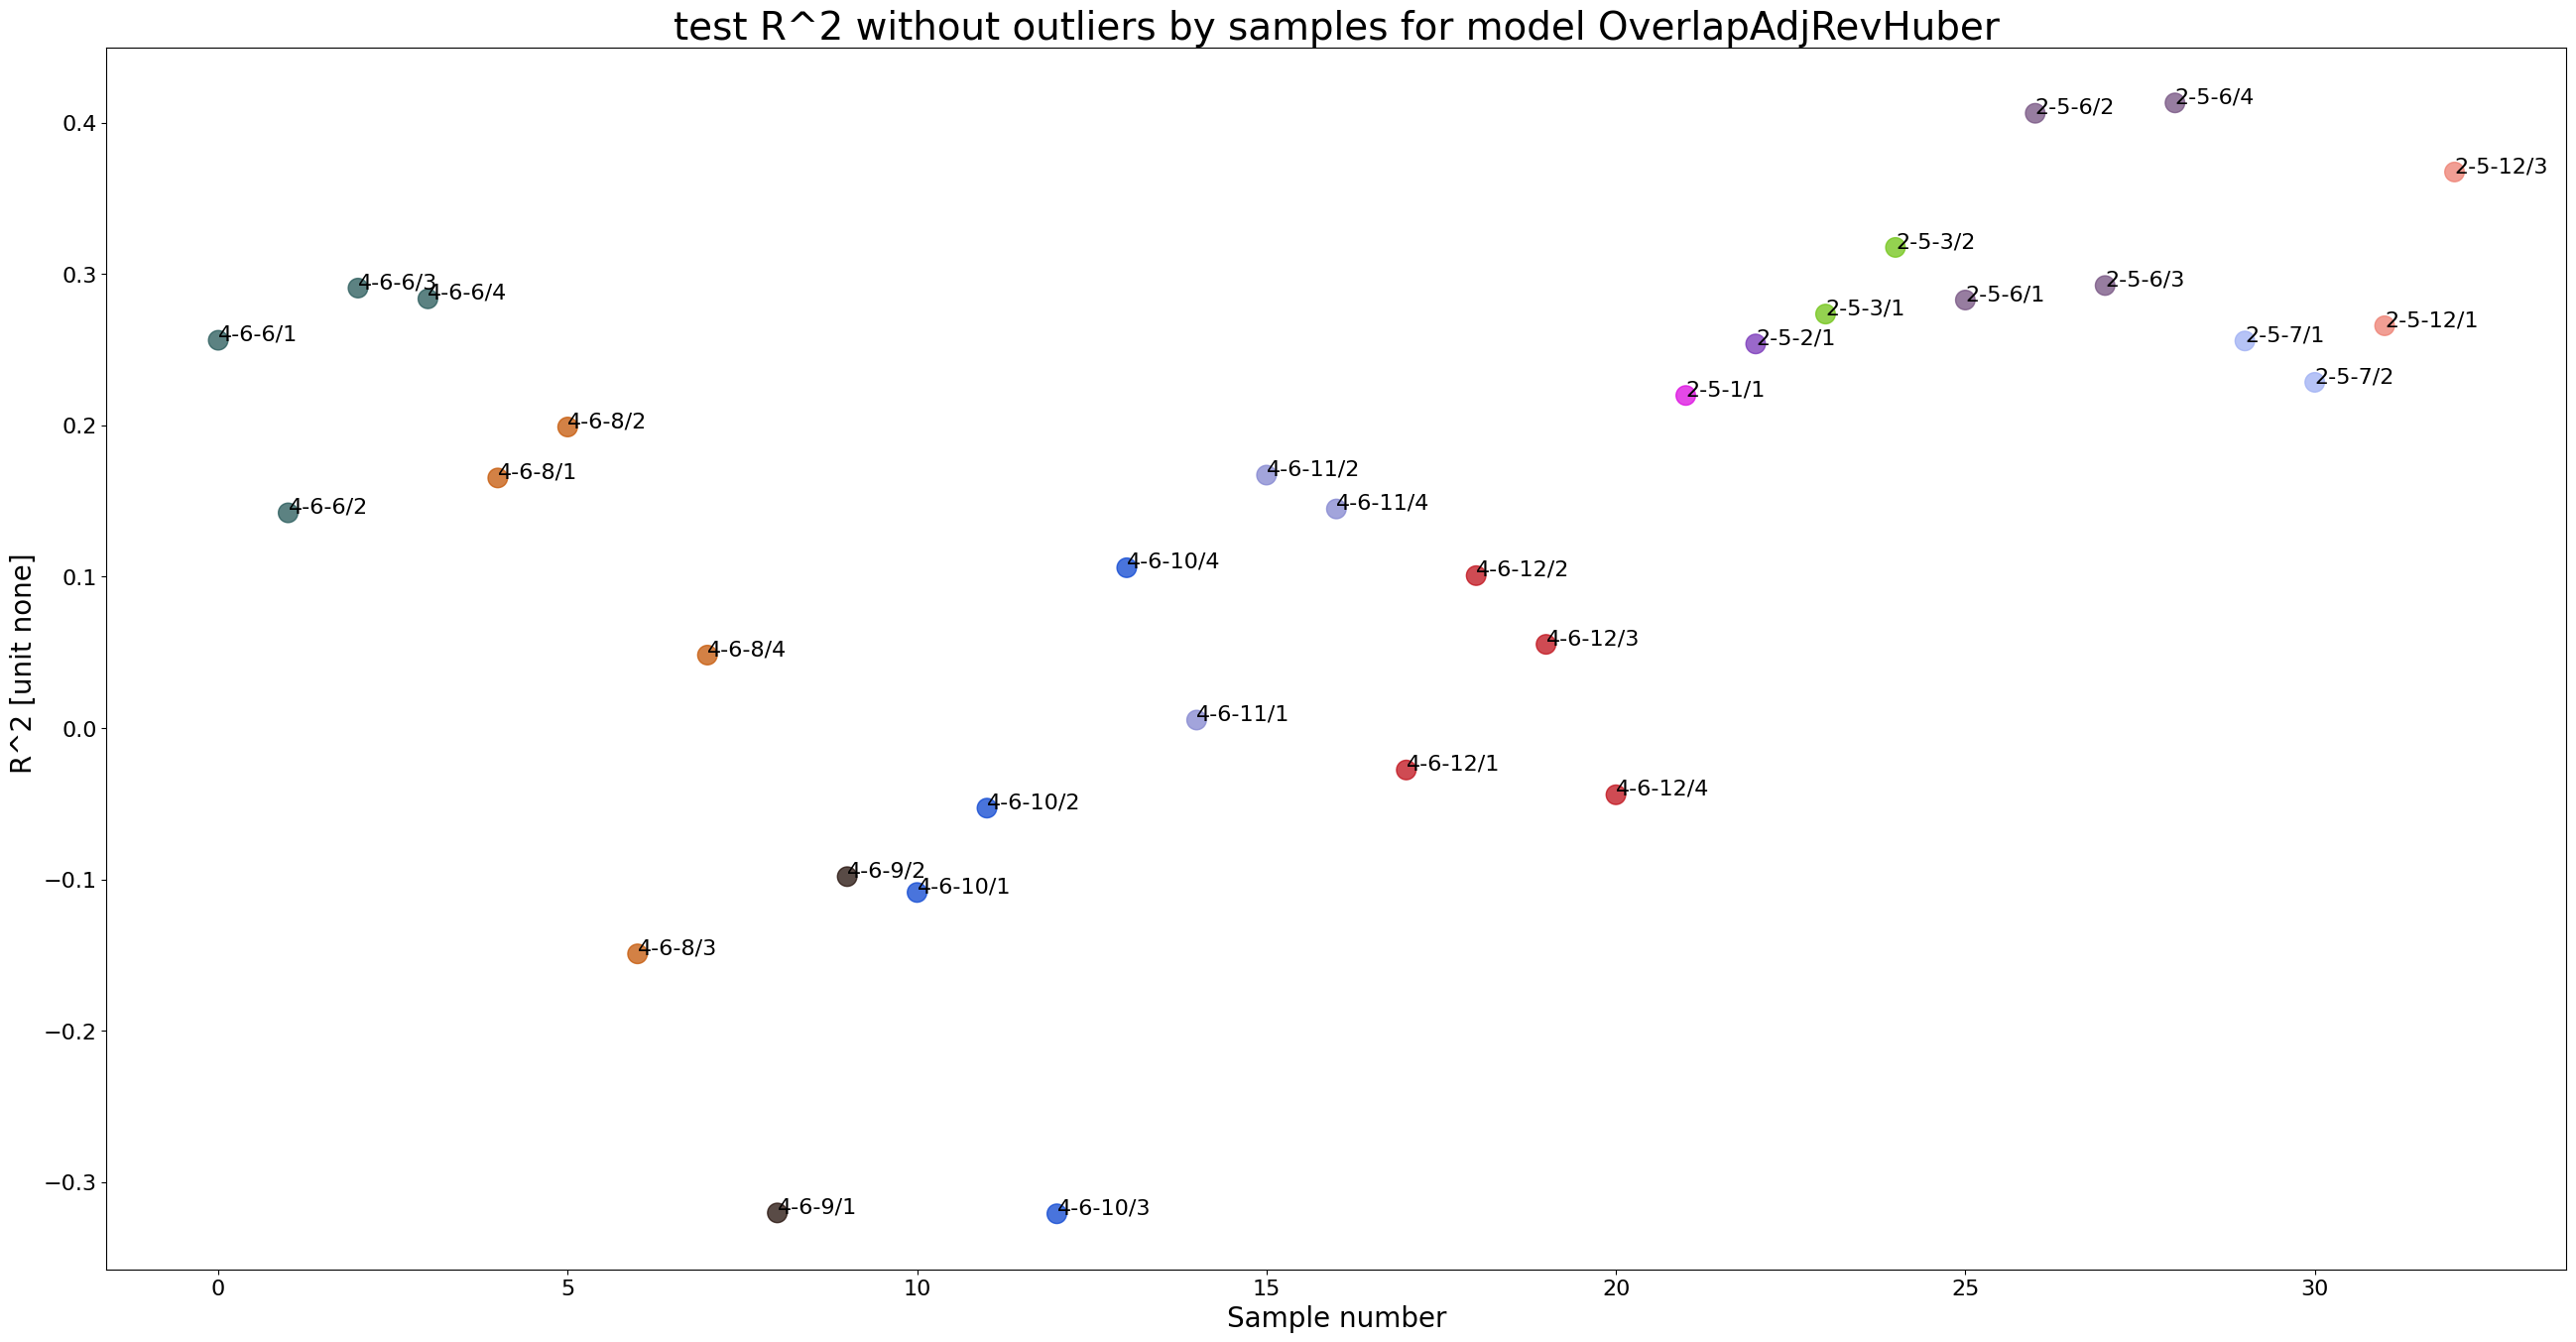

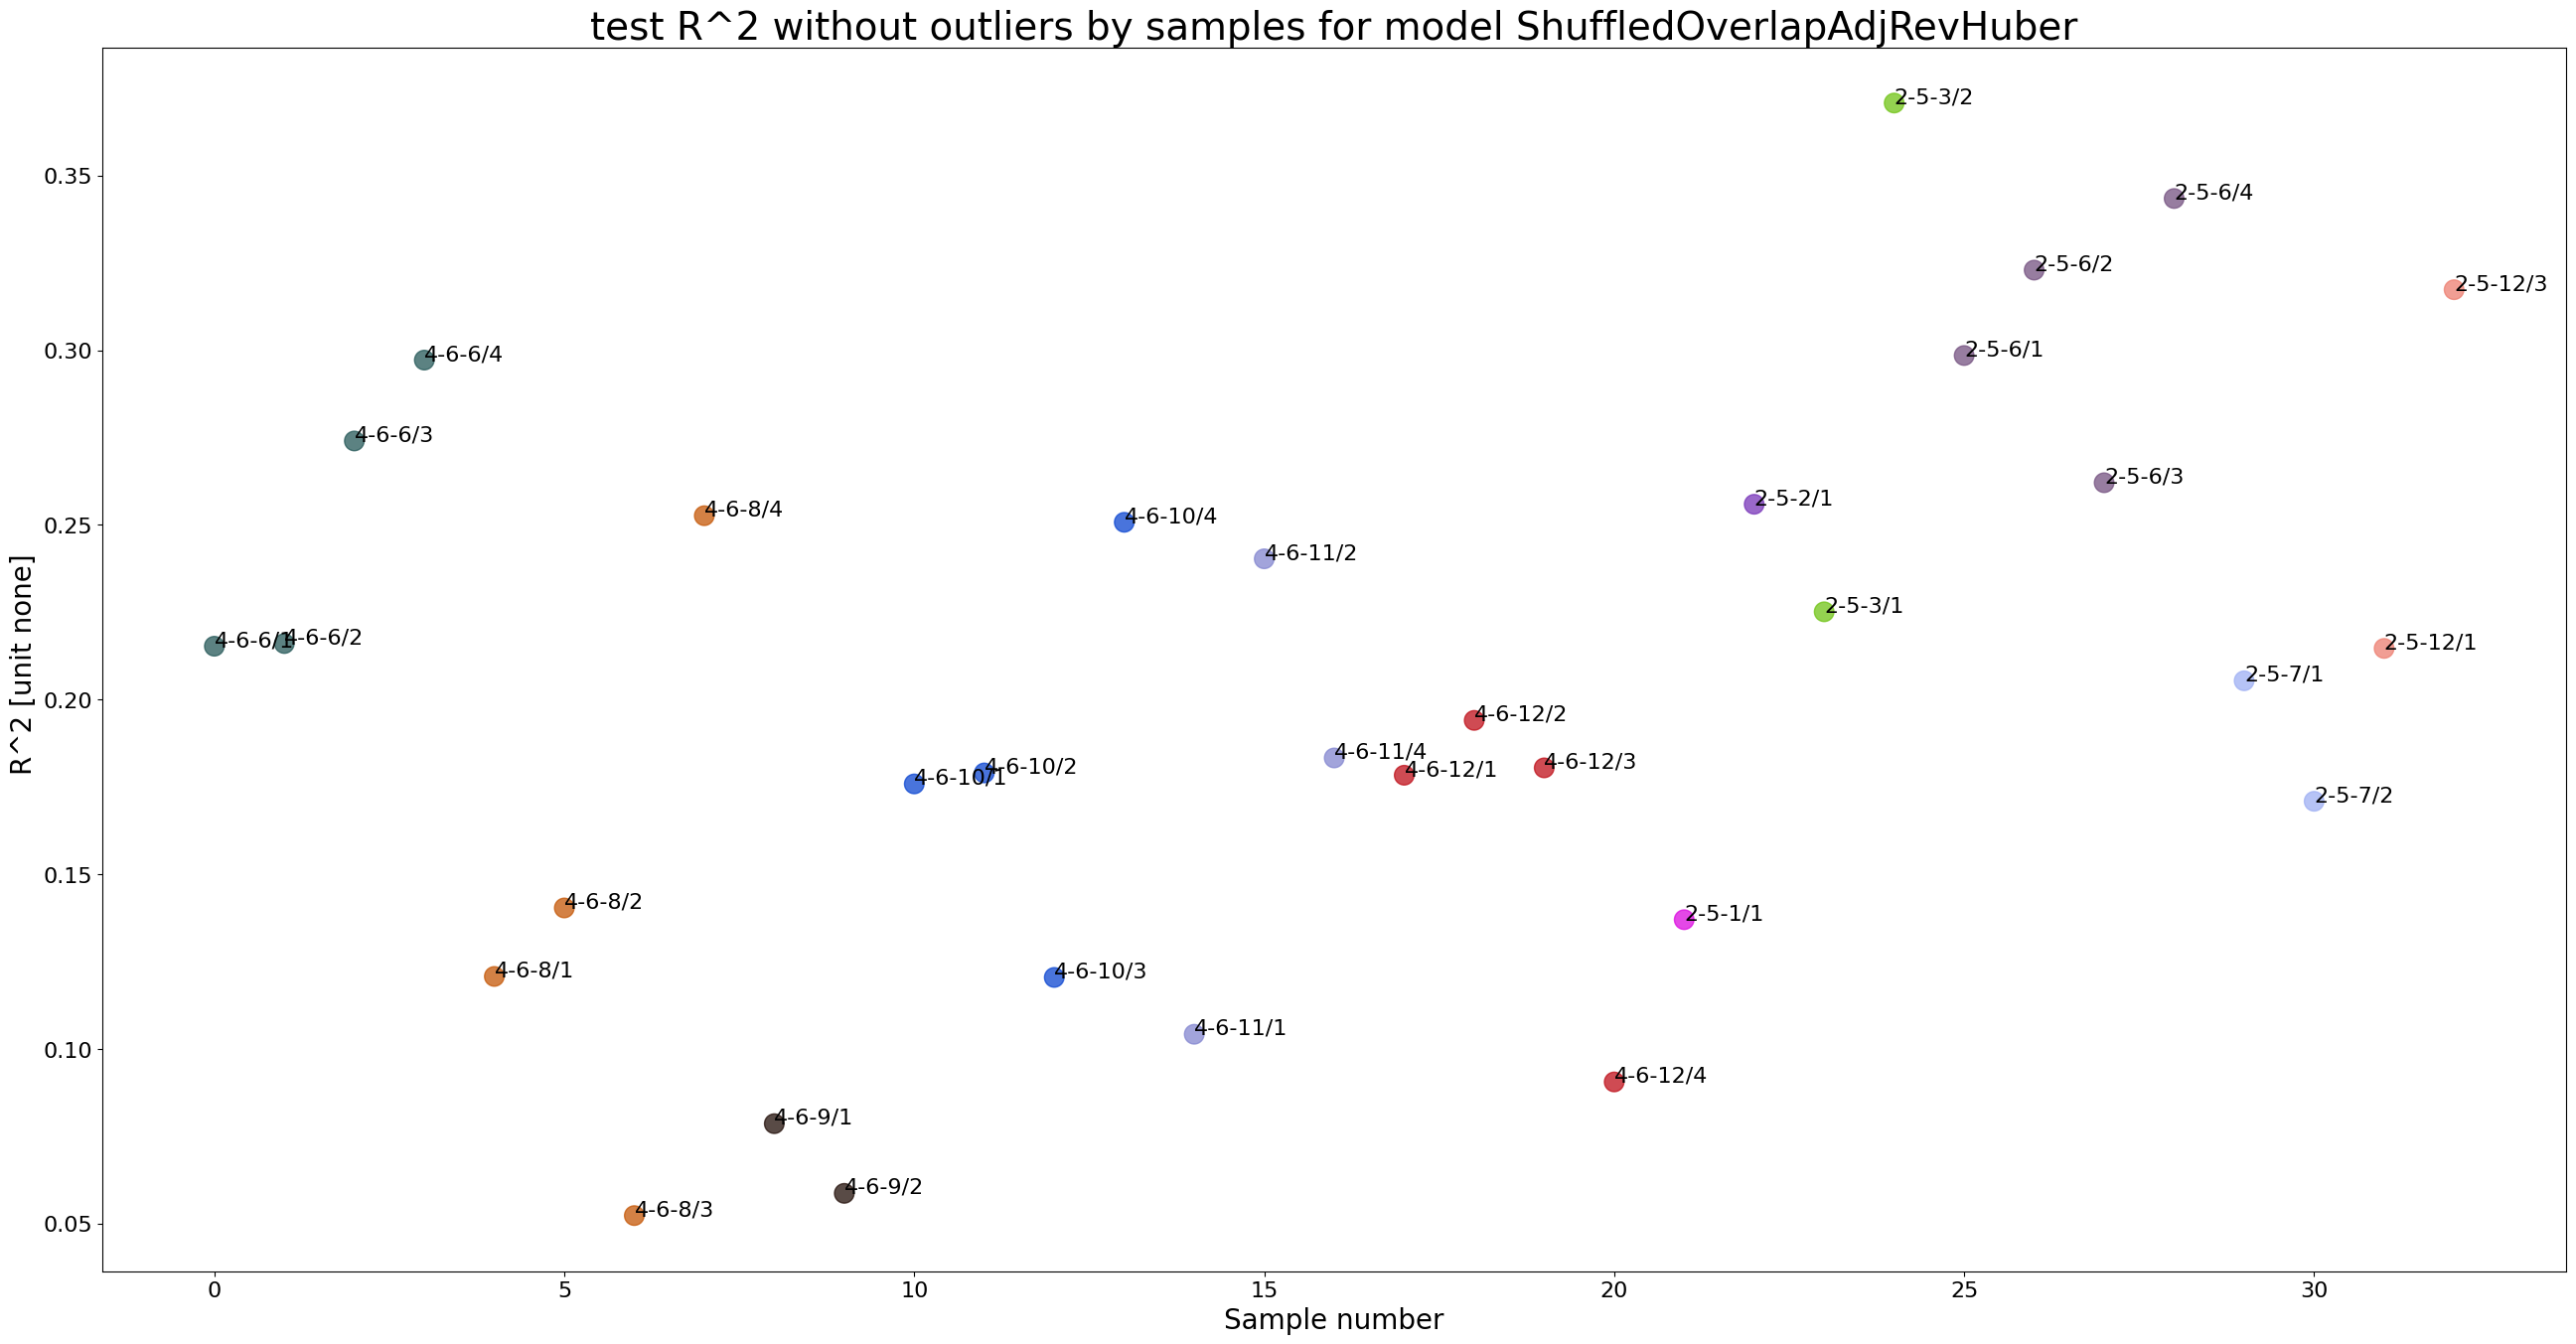

In [55]:
metrics = test_metrics_less

model_names = ['OverlapAdjRevHuber', "ShuffledOverlapAdjRevHuber"]

name='test'
    
#EXTRACT METRICS FROM DATASET
maes = []
rel_maes =[]
vol_loss_gt = []
vol_losses = []
r2 = []
filenames = []
materials_samples = []
maes_materials = []
rel_maes_materials=[]
vol_losses_materials = []
r2_materials = []

#SAVE ALL METRICS IN THE RIGHT FORMAT FOR TABLE
for m in metrics.keys():
    filenames_prof_temp = list(metrics[m]['metric_vals'].keys())
    #LOOK AT EACH SAMPLE FOR ONE MATERIAL
    for j in range(len(filenames_prof_temp)):
        prof_filename = filenames_prof_temp[j]

        if prof_filename not in not_to_use:
            if len(list(metrics[m]['metric_vals'][prof_filename].keys()))>0:
                r2.append(metrics[m]['metric_vals'][prof_filename]['r2'])
                maes.append(metrics[m]['metric_vals'][prof_filename]['mae'])
                rel_maes.append(metrics[m]['metric_vals'][prof_filename]['rel_mae'])
                vol_losses.append(metrics[m]['metric_vals'][prof_filename]['vol_loss'])
                vol_loss_gt.append(metrics[m]['metric_vals'][prof_filename]['vol_loss_gt'])
                filenames.append(prof_filename.split('/')[-2]+"/"+prof_filename.split('/')[-1][:-4])
                materials_samples.append(m)

maes = np.array(maes)
rel_maes = np.array(rel_maes)
vol_loss_gt = np.array(vol_loss_gt)
vol_losses = np.array(vol_losses)
r2 = np.array(r2).clip(-1, 1)
filenames = np.array(filenames)
materials_samples = np.array(materials_samples)

filenames_orig = copy.copy(filenames)

unique_materials = np.array(list(set(materials_samples)))
material_colors = {}
for mat in unique_materials:
    color_temp = "#"+''.join([random.choice('0123456789ABCDEF') for i in range(6)])
    material_colors[mat]=color_temp
    
    
vol_loss_shuffled = np.array(vol_losses[:, 1])


rel_maes_shuffled = rel_maes[:, 1]
vol_loss_gt = vol_loss_gt[rel_maes_shuffled<20]
vol_losses = vol_losses[rel_maes_shuffled<20]
r2 = r2[rel_maes_shuffled<20]
materials_samples = materials_samples[rel_maes_shuffled<20]
filenames = filenames[rel_maes_shuffled<20]
maes = maes[rel_maes_shuffled<20]
rel_maes = rel_maes[rel_maes_shuffled<20]

r2_shuffled = np.array(r2[:, 1])
vol_loss_gt = vol_loss_gt[r2_shuffled>0.05]
vol_losses = vol_losses[r2_shuffled>0.05]
r2 = r2[r2_shuffled>0.05]
materials_samples = materials_samples[r2_shuffled>0.05]
filenames = filenames[r2_shuffled>0.05]
maes = maes[r2_shuffled>0.05]
rel_maes = rel_maes[r2_shuffled>0.05]


num_models = len(maes[0])

#SAVE VOLUME LOSS VS GROUND TRUTH VOLUME LOSS BY SAMPLES FOR MODEL ID
for model_id in range(num_models):
    save_metric(ylabel_name = "Ground truth volume loss [unit nm^3]", xlabel_name="Predicted volume loss [unit nm^3]", samples_material = materials_samples, colors_material= material_colors, filenames=filenames, metric=vol_losses[:, model_id], metric_name="vol_loss_samples without outliers", dataset_name=name, title=name+" volume loss prediction vs GT by samples for model {}".format(model_names[model_id]), metric2=vol_loss_gt, model_name =model_names[model_id])

#SAVE R2 BY SAMPLES FOR MODEL ID
for model_id in range(num_models):    
    save_metric(ylabel_name = 'R^2 [unit none] ', xlabel_name="Sample number", samples_material = materials_samples, colors_material= material_colors, filenames=filenames, metric=r2[:, model_id], metric_name="r2_samples", dataset_name=name, title=name + " R^2 without outliers by samples for model {}".format(model_names[model_id]), model_name =model_names[model_id])


#return maes, rel_maes, vol_loss_gt, vol_losses, r2

In [37]:
np.setdiff1d(filenames_orig, filenames)

array(['2-5-11/1', '2-5-11/2', '2-5-3/3', '2-5-5/1', '2-5-5/2', '2-5-5/3',
       '2-5-5/4', '2-5-7/3', '4-6-11/3', '4-6-7/1', '4-6-7/2', '4-6-7/3',
       '4-6-7/4', '4-6-9/3', '4-6-9/4'], dtype='<U8')

In [56]:
import scipy

In [58]:
scipy.stats.pearsonr(vol_losses[:, 0], vol_loss_gt)

PearsonRResult(statistic=0.4174290451414461, pvalue=0.015649565433096965)

In [59]:
scipy.stats.pearsonr(vol_losses[:, 1], vol_loss_gt)

PearsonRResult(statistic=0.5200983664307242, pvalue=0.0019193592146720926)

In [62]:
r2[:, 0].mean()

0.13386627587383404

In [63]:
r2[:, 1].mean()

0.2038651003271745